Author(s) : Daniel R., Tarry, Laura Gómez Navarro, Elisabet Verger-Miralles

Objective: Describe xxx

Created on: October 2023

Last updated on:


In [1]:
import time

print(time.ctime(time.time()))

Tue Apr  2 19:31:39 2024


In [2]:
import sys
sys.path.insert(0, "../../processing/")

In [3]:
import numpy as np
import xarray as xr # version 0.20.1 necesarry, 0.16 gives error when calculating u_for
import matplotlib.pyplot as plt
import scipy.signal as signal

import cartopy
import cartopy.crs as ccrs
import cartopy.feature       as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

from read_data_tools import latlon2uv_dir

In [4]:
# version_information

In [5]:
print(xr.__version__)

2023.6.0


# Parameters:

In [6]:
url_drifter = "drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?"
drifter_type = 'C' # C: CARTHE ; H: Hereon ; S: SVP-B 

# n_window = 12 # we leave like this for now

In [7]:
# Parameters
url_drifter = "drifter_hereon018-ime_hereon018/L0/2023/dep0001_drifter-hereon018_ime-hereon018_L0_2023-05-10.nc?"
drifter_type = "H"
diff_time_thres = 3600
temp_res = 600.0


# CARTHE example

# 1. Loading the data:

In [8]:
# Main root
url_root = "http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/"

In [9]:
# parameters of the thredd file

if drifter_type == 'C':
    url_vars = "trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]"
    temp_res = 600. # Specifying seconds 
    # Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
elif drifter_type == 'H':
    url_vars = "trajectory,time[0:1:-1],LAT[0:1:-1],LON[0:1:-1],DEPTH,PLAT_SPEED_GR[0:1:-1],PLAT_COURSE[0:1:-1],BAT_STATUS[0:1:-1]"
    temp_res = 600. # Specifying seconds 
    # Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
elif drifter_type == 'S':
    url_vars = "trajectory,time[0:1:-1],DEPTH,WTEM[0:1:-1],VOLT[0:1:-1],LAT[0:1:-1],DROGUE[0:1:-1],LON[0:1:-1],APRE[0:1:-1]"
    temp_res = 3600. # Specifying seconds 
else:
    print('Hereon is the same, add option, SVP missing temp , press , BAT_status different')
    fsdfs

In [10]:
# Load file

url = url_root + url_drifter + url_vars
 
print(url)

ds00 = xr.open_dataset(url)


http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_hereon018-ime_hereon018/L0/2023/dep0001_drifter-hereon018_ime-hereon018_L0_2023-05-10.nc?trajectory,time[0:1:-1],LAT[0:1:-1],LON[0:1:-1],DEPTH,PLAT_SPEED_GR[0:1:-1],PLAT_COURSE[0:1:-1],BAT_STATUS[0:1:-1]


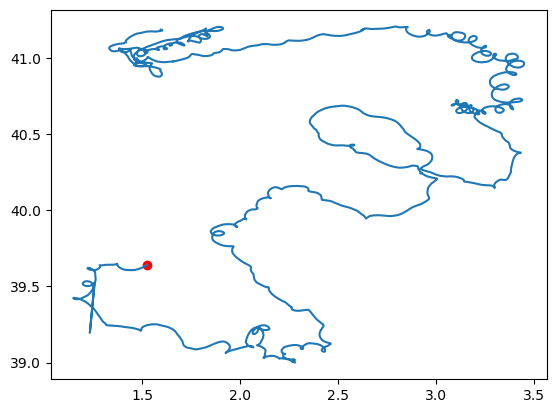

In [11]:

plt.plot(ds00.LON, ds00.LAT)
plt.scatter(ds00.LON[0], ds00.LAT[0], c='r')

# 2. Processing:

In [12]:
# Checking time interval:

print(ds00.time[0].data)
print(ds00.time[1].data)

# --> Should be: 
# 10 mins freq. for CARTHE
# 5 mins HEREON
# 1h SVP-B

2023-05-10T03:47:16.000000000
2023-05-10T03:57:26.000000000


## 2.1. Identifying large time gaps (to kill drifter traj trash)

### 1 hour:

In [13]:
diff_time_thres = 3600 # [s] 1h

In [14]:
dt_drif = ds00.time.diff("time").dt.seconds

In [15]:
# just using np.where, find cleaner method with array to find indices:

In [16]:
inds_trash = np.where(dt_drif > diff_time_thres)[0]
print(inds_trash)
print(inds_trash.size)

[2266 8638]
2


In [17]:
if inds_trash.size > 0: 
    ds01 = ds00.where(ds00.time<ds00.time[inds_trash[0]+2], drop=True) # to improve 
    # + 2 because +1 of normal python indices , and 1 more because based on the indices of the array of time differences
elif inds_trash.size == 0:
    ds01 = ds00.copy()
else:
    print('Problem')
    fsdgsdfg

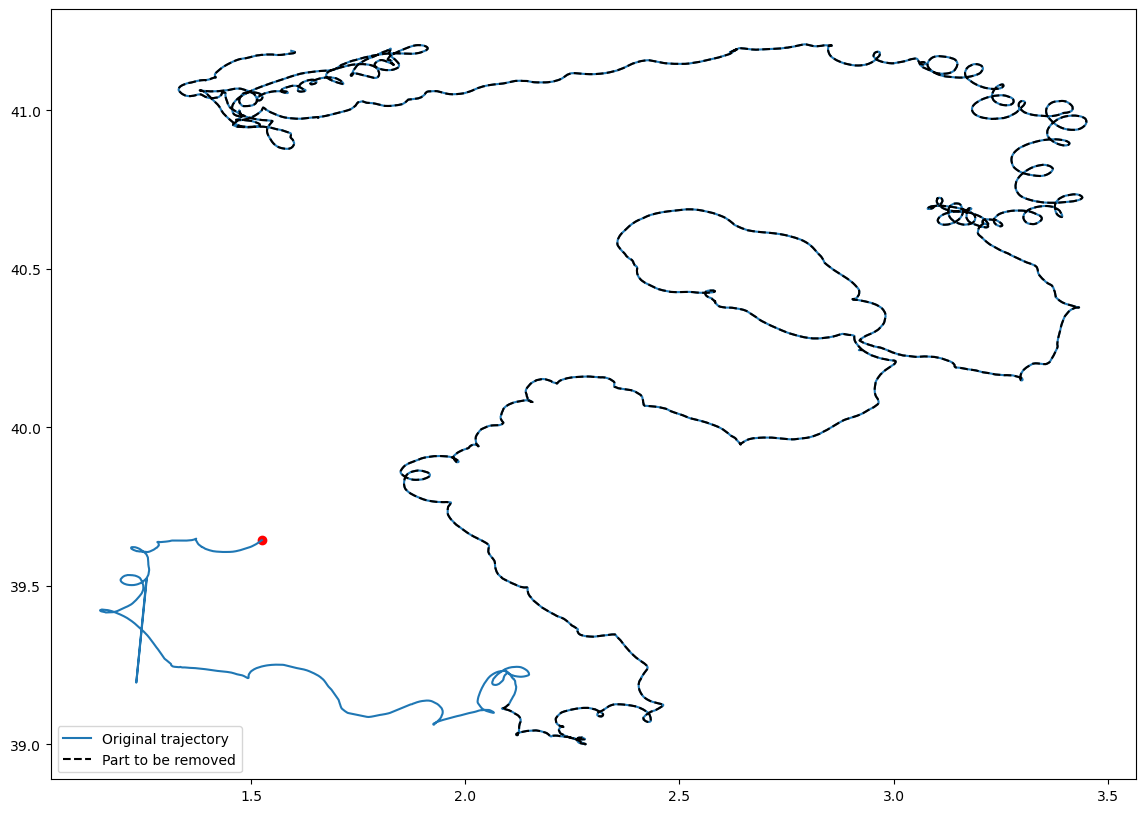

In [18]:
if inds_trash.size > 0: 
    plt.figure(figsize=(14,10))
    plt.plot(ds00.LON, ds00.LAT, label='Original trajectory')
    plt.scatter(ds00.LON[0], ds00.LAT[0], c='r')
    plt.plot(ds00.LON[inds_trash[0]::], ds00.LAT[inds_trash[0]::], '--k', label='Part to be removed')
    plt.legend()
else:
    print(f'Nothing to plot, no gap bigger than {diff_time_thres/3600} hours')

# --> we cut the traj. from the green part, although it looks good, something to revisit!

# 2 hours cut:

In [19]:
diff_time_thres = 3600 * 2 # [s] 1h

In [20]:
dt_drif = ds00.time.diff("time").dt.seconds

In [21]:
inds_trash = np.where(dt_drif > diff_time_thres)[0]
print(inds_trash)
print(inds_trash.size)

[]
0


In [22]:
if inds_trash.size > 0: 
    ds01 = ds00.where(ds00.time<ds00.time[inds_trash[0]+2], drop=True) # to improve 
    # + 2 because +1 of normal python indices , and 1 more because based on the indices of the array of time differences
elif inds_trash.size == 0:
    ds01 = ds00.copy()
else:
    print('Problem')
    fsdgsdfg

In [23]:
if inds_trash.size > 0: 
    plt.figure(figsize=(14,10))
    plt.plot(ds00.LON, ds00.LAT, label='Original trajectory')
    plt.scatter(ds00.LON[0], ds00.LAT[0], c='r')
    plt.plot(ds00.LON[inds_trash[0]::], ds00.LAT[inds_trash[0]::], '--k', label='Part to be removed')
    plt.legend()
else:
    print(f'Nothing to plot, no gap bigger than {diff_time_thres/3600} hours')

Nothing to plot, no gap bigger than 2.0 hours


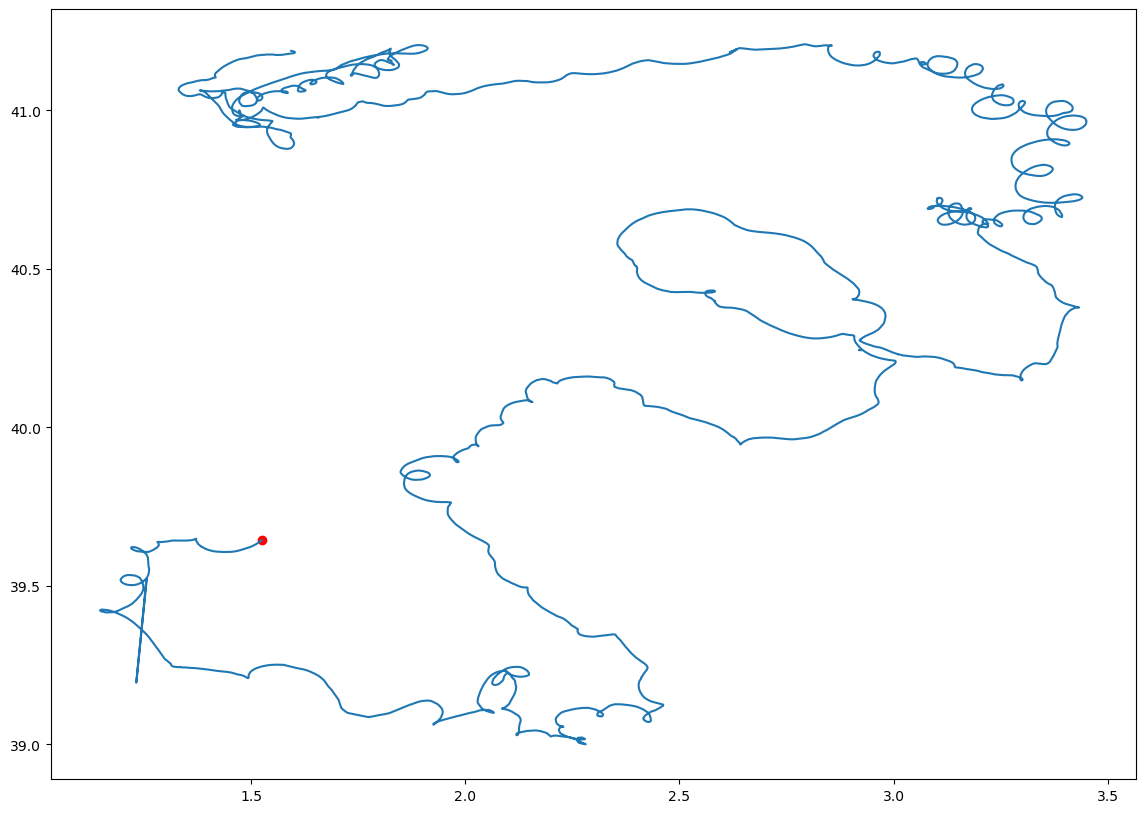

In [24]:
plt.figure(figsize=(14,10))
plt.plot(ds01.LON, ds01.LAT)
plt.scatter(ds01.LON[0], ds01.LAT[0], c='r')

## 2.2. Resampling to regular 10 mins. intervals:
(constant 10 mins and "o'clock" times)

### 2.2.1. Making lon and lat variables instead of coordinates
If we do not do this step when resampling we loose lon and lat in the dataset.  To keep in mind that this may give problems in further calculations with xarray that might need lon and lat as coords.

In [25]:
ds01 = ds01.reset_coords("LON")
ds01 = ds01.reset_coords("LAT")

In [26]:
ds01

<xarray.Dataset>
Dimensions:        (time: 21712)
Coordinates:
  * time           (time) datetime64[ns] 2023-05-10T03:47:16 ... 2023-07-30T1...
    DEPTH          float64 ...
Data variables:
    trajectory     |S64 ...
    LAT            (time) float64 39.64 39.64 39.64 39.64 ... 41.19 41.19 41.19
    LON            (time) float64 1.524 1.522 1.521 1.52 ... 1.594 1.593 1.593
    PLAT_SPEED_GR  (time) float64 ...
    PLAT_COURSE    (time) float64 ...
    BAT_STATUS     (time) float64 ...
Attributes: (12/67)
    title:                               Data from instrument IME-HEREON018 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-HEREON018 in FaSt-...
    summary:                             Deployment of IME-HEREON018 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

### 2.2.2. Resampling:

In [27]:
ds02 = ds01.resample(time=f"{int(temp_res)}s").interpolate("linear") # xarray resample works very differently from pandas


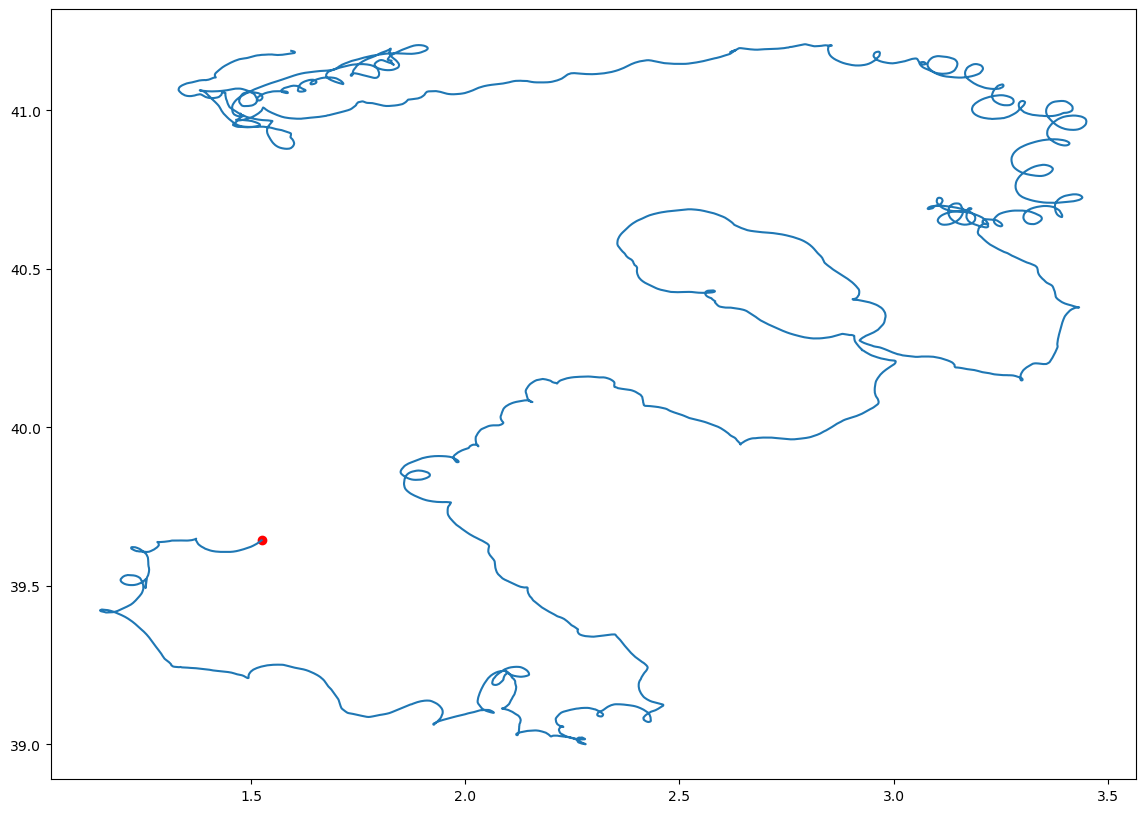

In [28]:
plt.figure(figsize=(14,10))
plt.plot(ds02.LON, ds02.LAT)
# plt.scatter(ds02.LON[0], ds02.LAT[0], c='r') # first point is nan now
plt.scatter(ds02.LON[1], ds02.LAT[1], c='r')

# --> spikes now smaller but still present
# To improve: maybe better to remove spikes with lon and lat (thres 0.02?) before resampling so that spike not spread

## 2.3. Calculate forward and backward velocities

In [29]:
# Calculate forward and backward finite differences
speed, ufor, vfor = latlon2uv_dir(ds02.LAT, ds02.LON, 10*60, 'forward')
_, uback, vback = latlon2uv_dir(ds02.LAT, ds02.LON, 10*60, 'back')

In [30]:
# Calculate central value
u = (ufor + uback) / 2
v = (vfor + vback) / 2


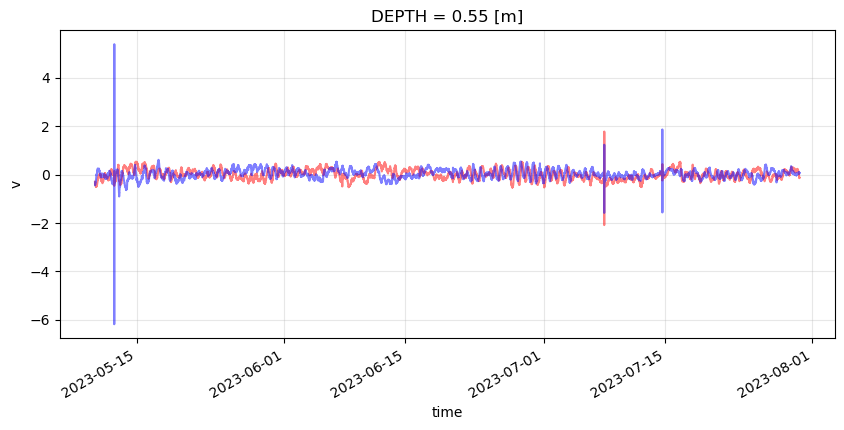

In [31]:
# Check values for spikes
plt.figure(figsize=(10,4))
u.plot(alpha = 0.5, color = "red");
v.plot(alpha = 0.5, color = "blue");
plt.grid(alpha=0.3)

In [32]:
# Add variables to the dataset
ds02 = ds02.assign(U=u)
ds02 = ds02.assign(V=v)
print(list(ds02.keys()))

['trajectory', 'LAT', 'LON', 'PLAT_SPEED_GR', 'PLAT_COURSE', 'BAT_STATUS', 'U', 'V']


In [33]:
ds02.U.values

array([        nan, -0.30015959, -0.32480979, ..., -0.14667012,
       -0.13486956,         nan])

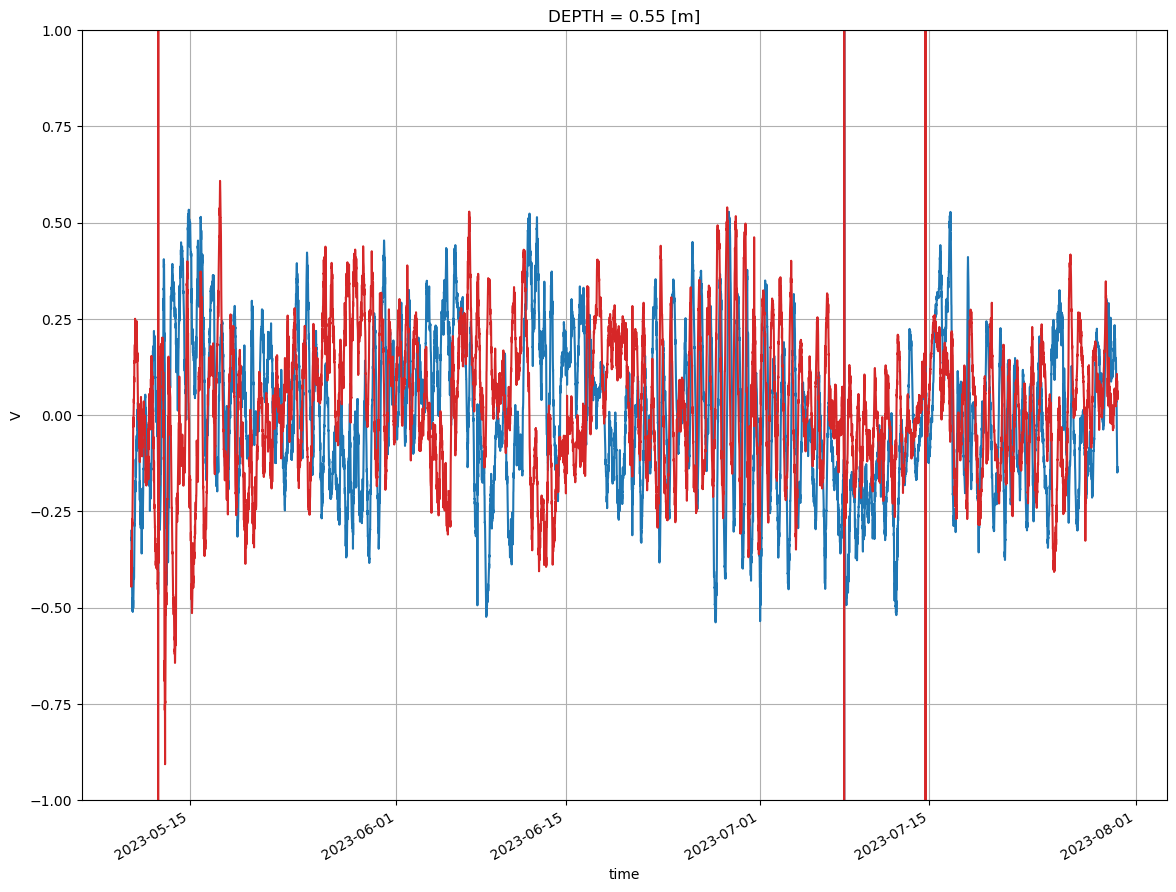

In [34]:
ds02.U.plot(figsize=(14,10))
ds02.V.plot(c='C3')
plt.ylim([-1, 1])
plt.grid()

## 2.4. Spike cleaning:



Cleaning spikes now based on velocity thresholds(absolute velocity (speed))

We will look velocity’s module magnitude to identify spikes due to spurious data







In [35]:
abs_vel = (ds02.U**2 + ds02.V**2)**0.5

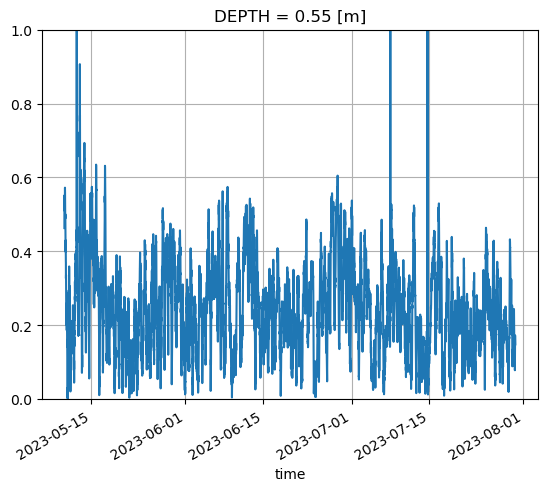

In [36]:
abs_vel.plot()
plt.ylim([0,1])
plt.grid()

### 2.4.1. Large spikes removal

Based on above plot we choose 0.8 m/s.

To improve:
- big spike cleaning with lon and lat thres. before resmpling
- do a moving vel. thres.
- would be better to filter spikes on acceleration, but harder then to choose threshold (less intuitive)

In [37]:
vel_thres = 0.8 # m/s # 1.5 se cuelan spikes # 1. also lowe limits pikes se cuela

In [38]:
ds03 = ds02.where(abs_vel < vel_thres)

In [39]:
abs_vel_thres = (ds03.U**2 + ds03.V**2)**0.5

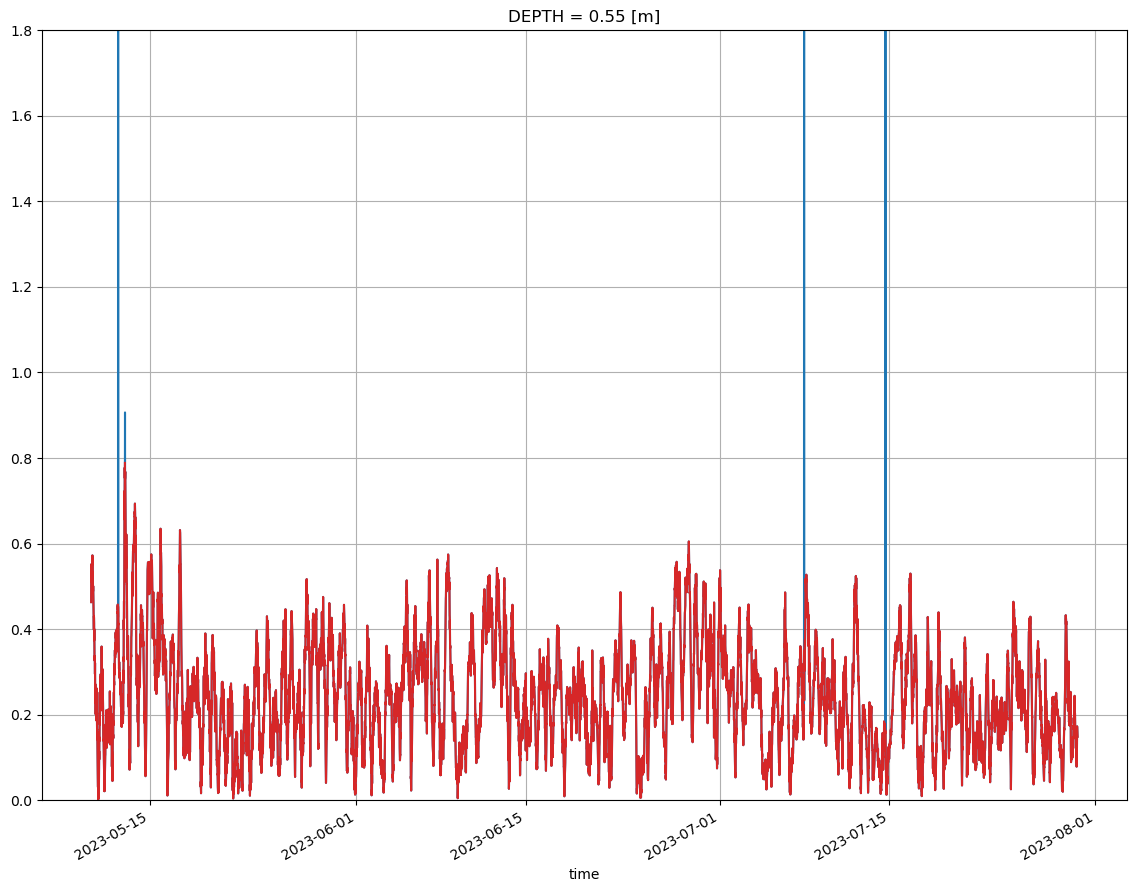

In [40]:
abs_vel.plot(figsize=(14,10))
abs_vel_thres.plot(c='C3')
plt.ylim([0,1.8])
plt.grid()

/opt/anaconda3/envs/venv_fswot/lib/python3.11/site-packages/xarray/plot/utils.py:465: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, ax = plt.subplots(figsize=figsize, subplot_kw=subplot_kws)


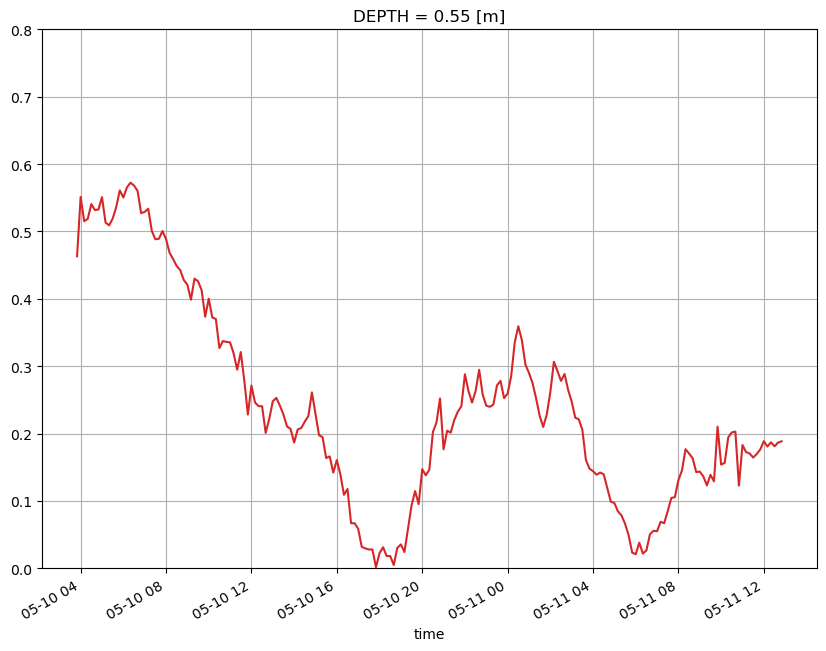

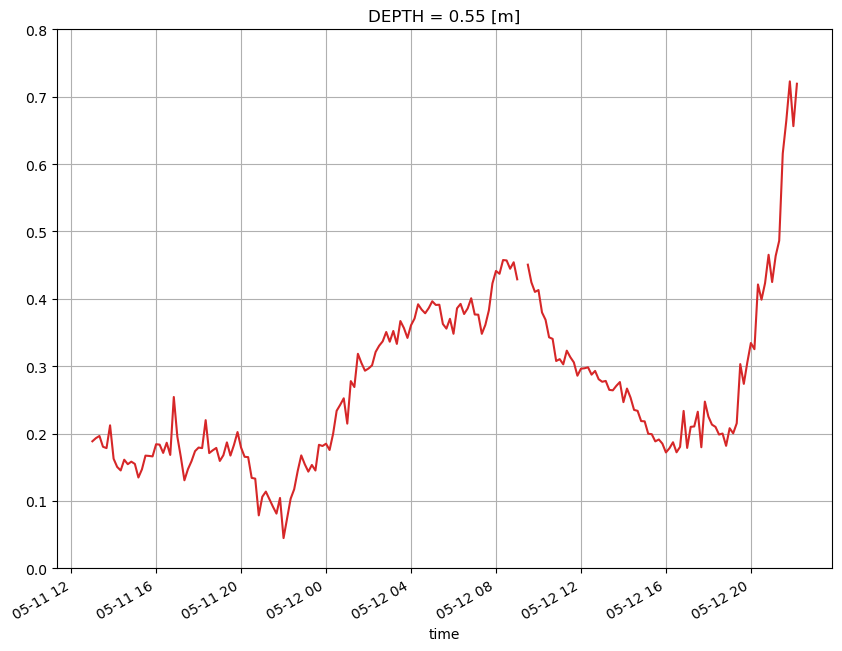

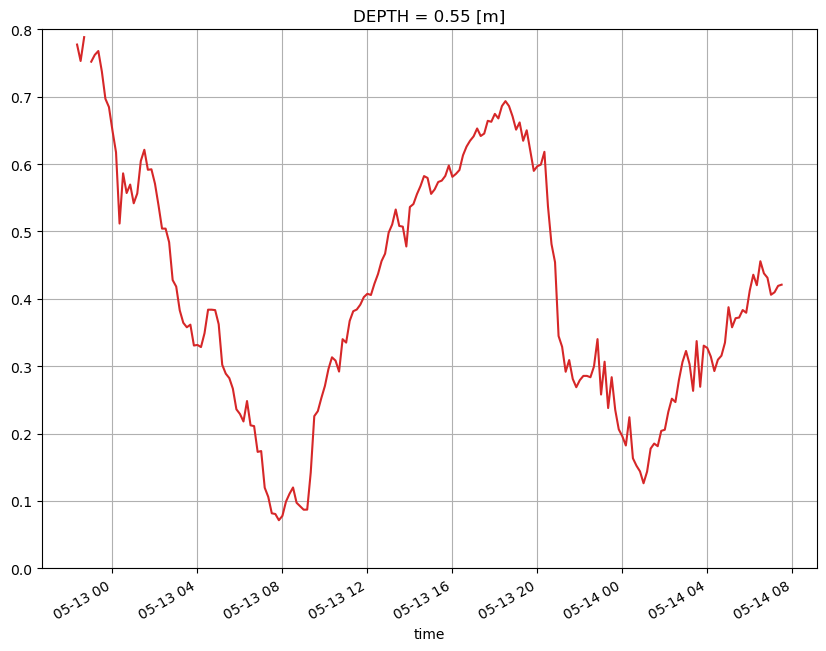

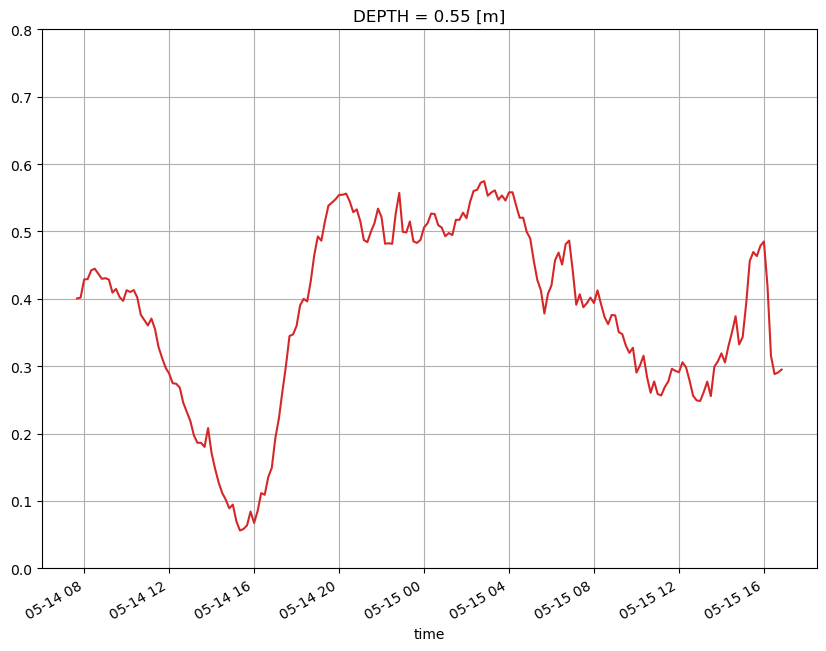

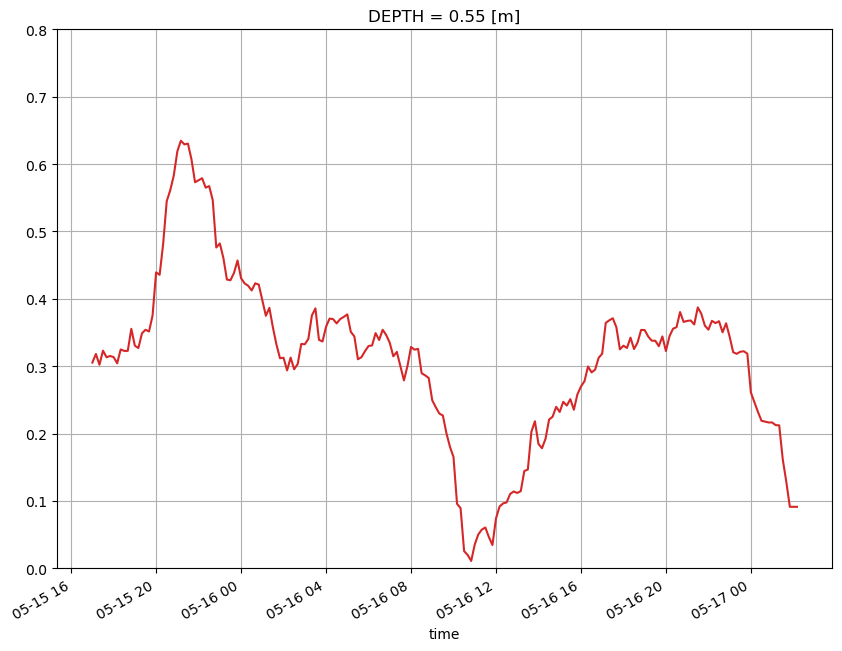

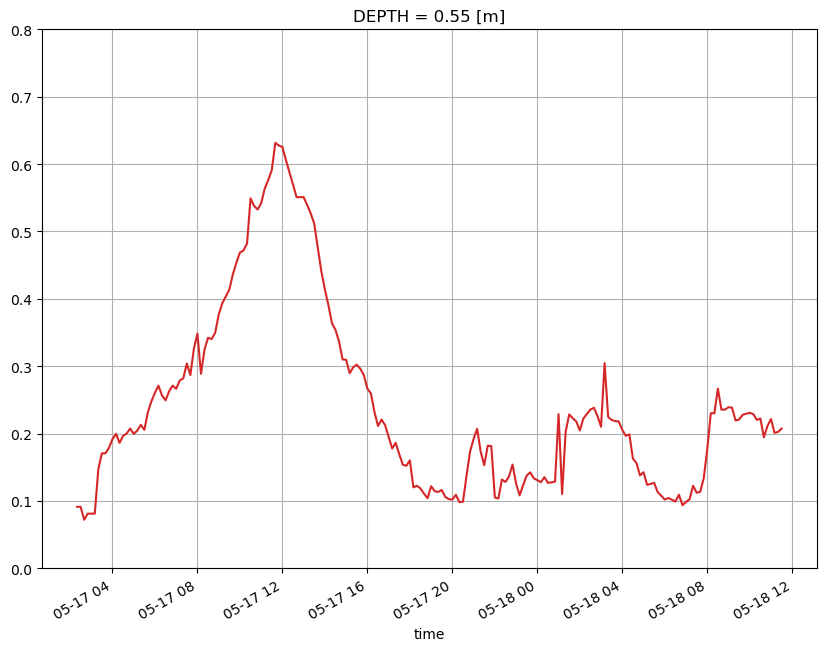

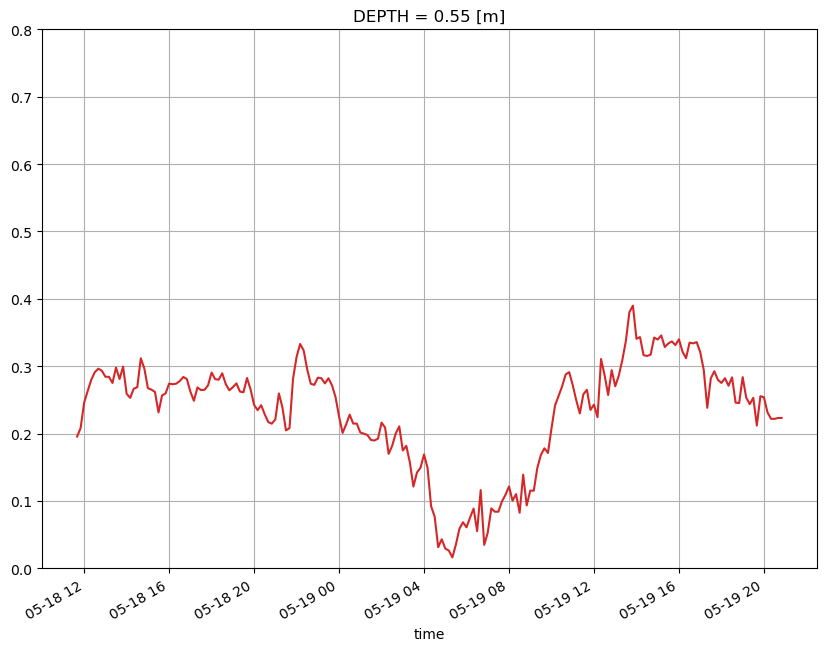

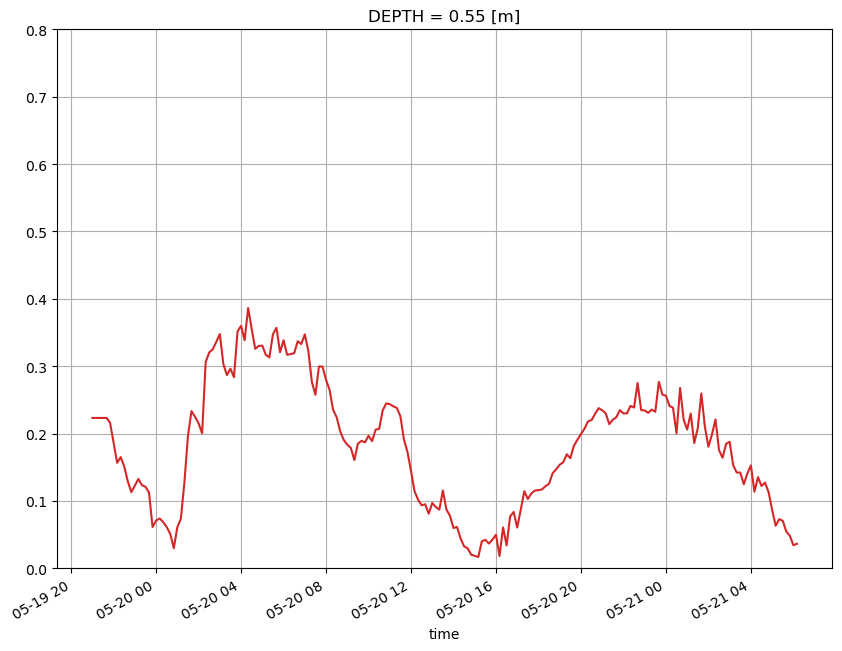

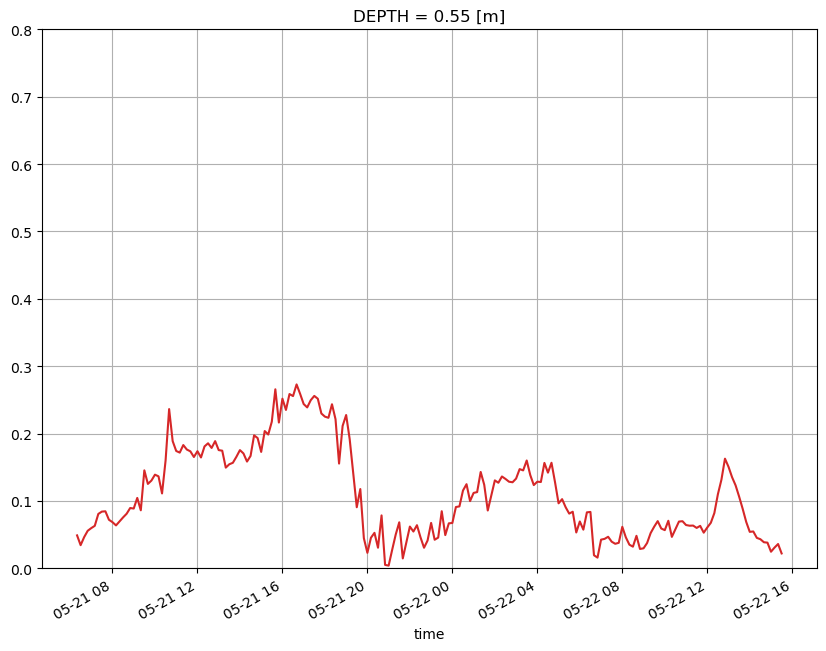

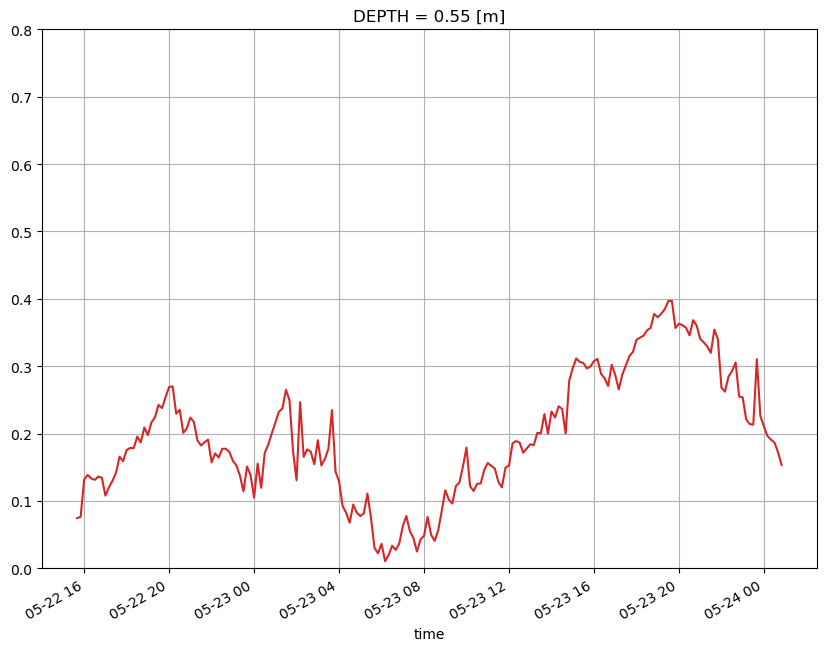

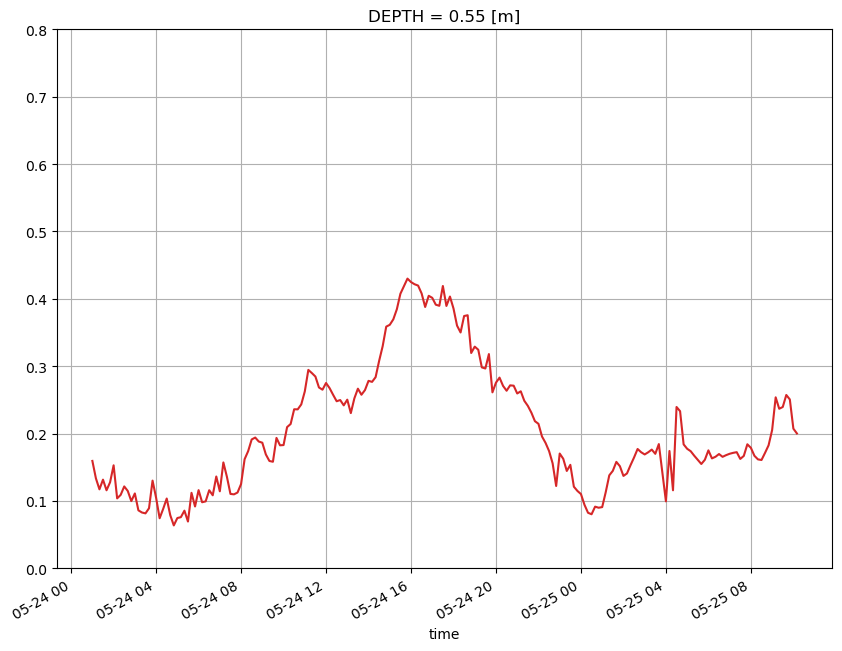

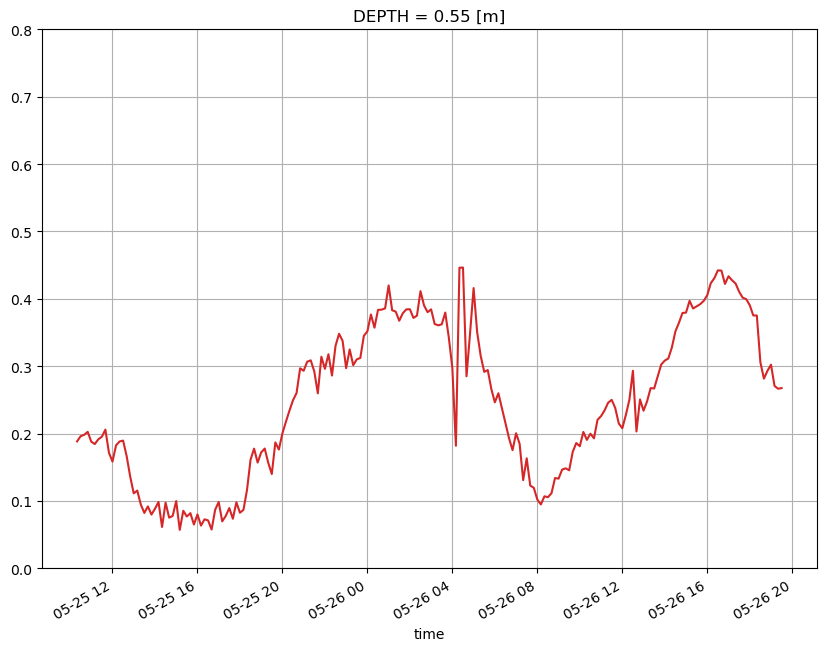

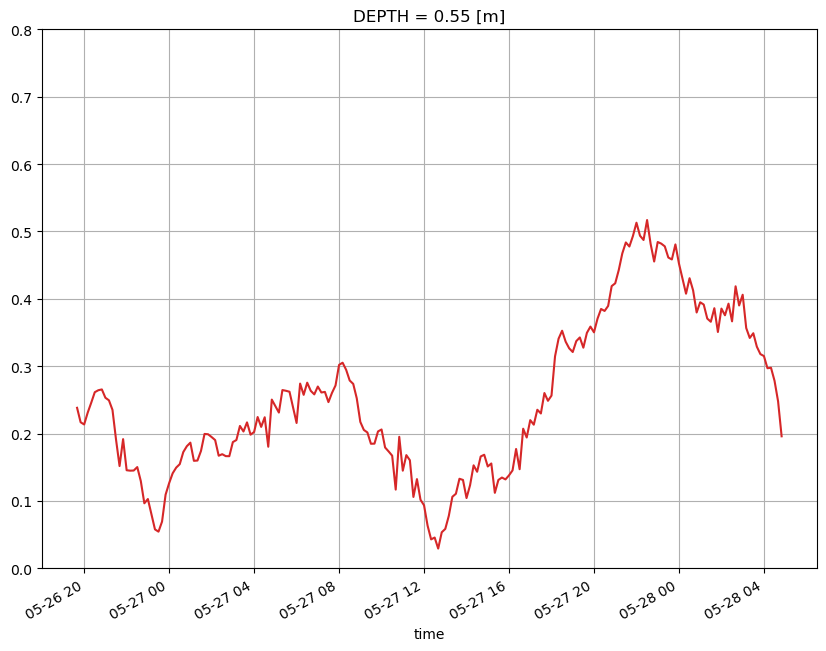

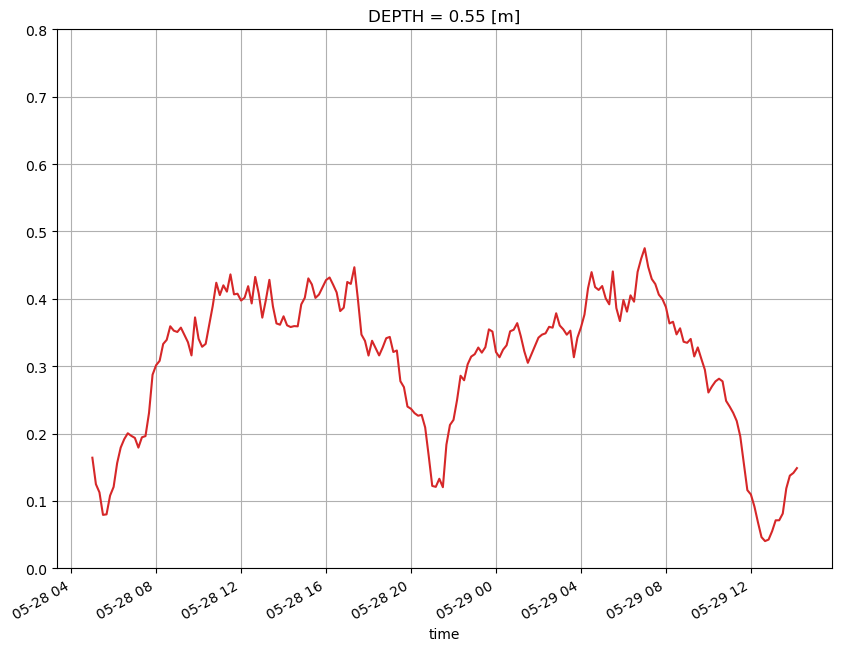

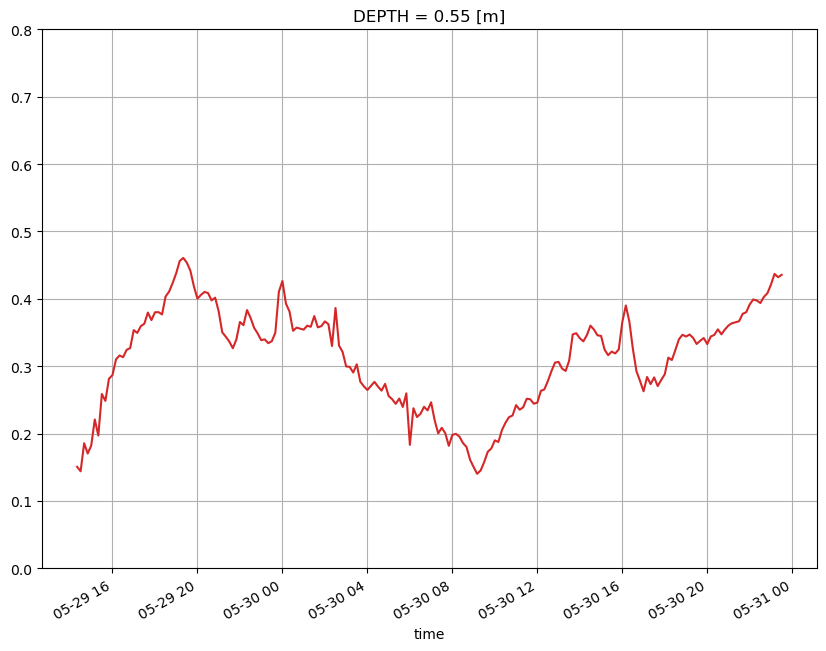

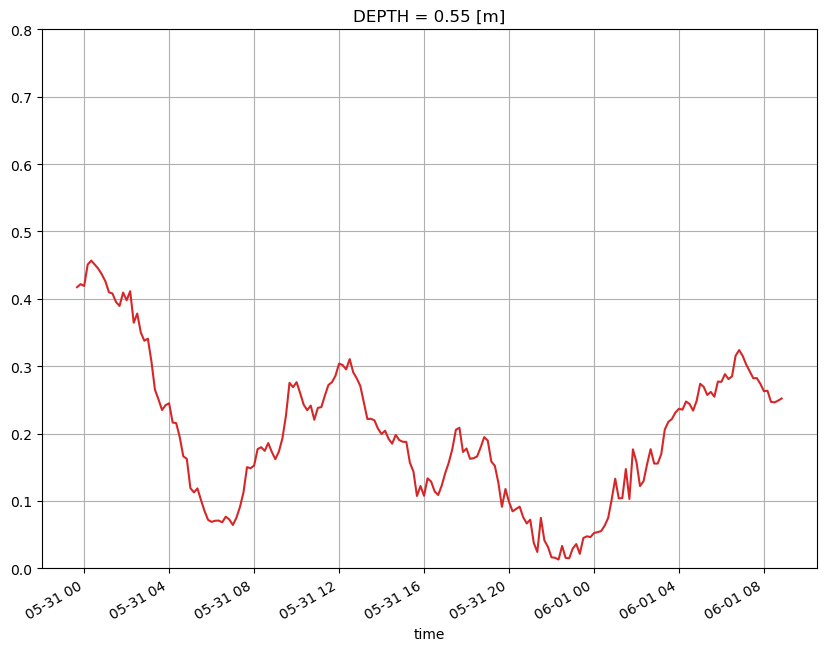

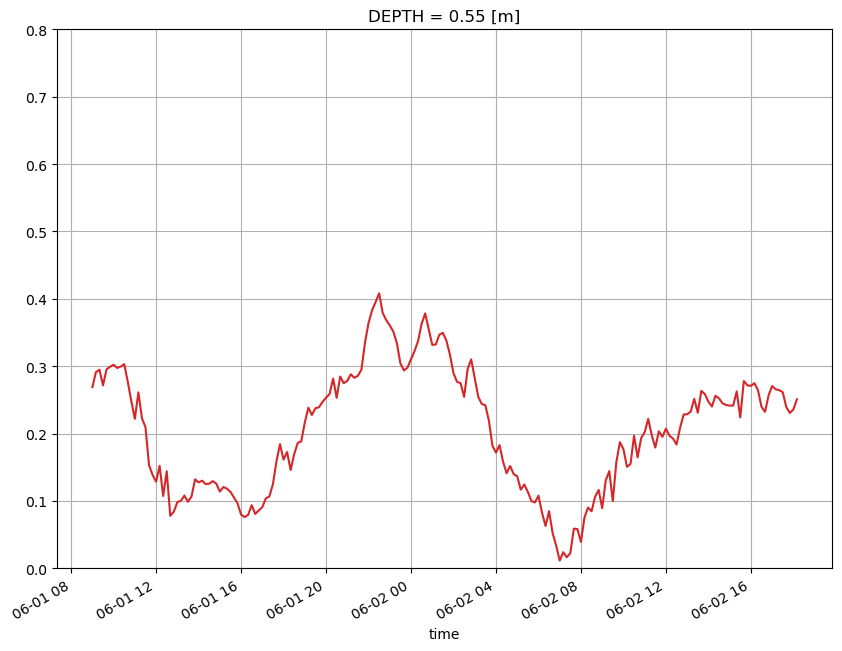

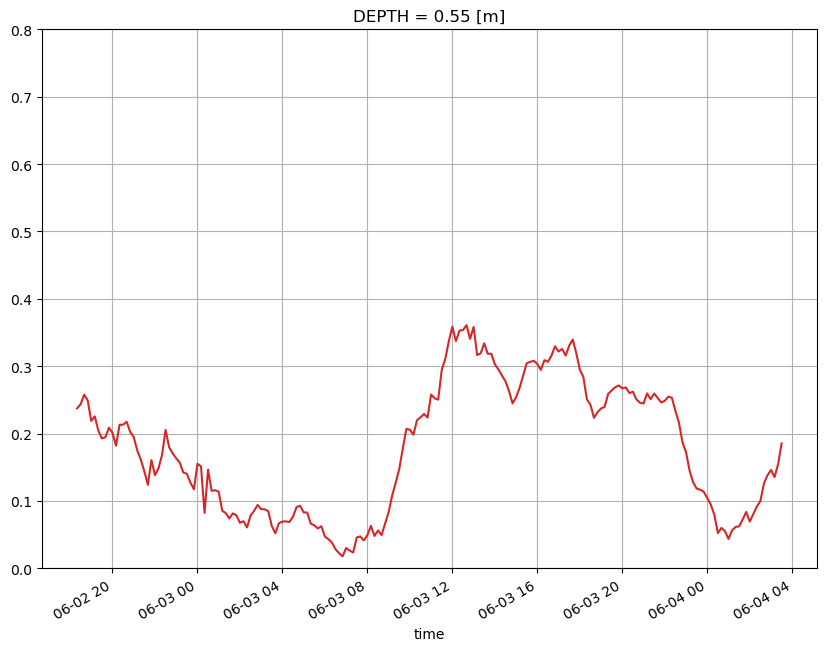

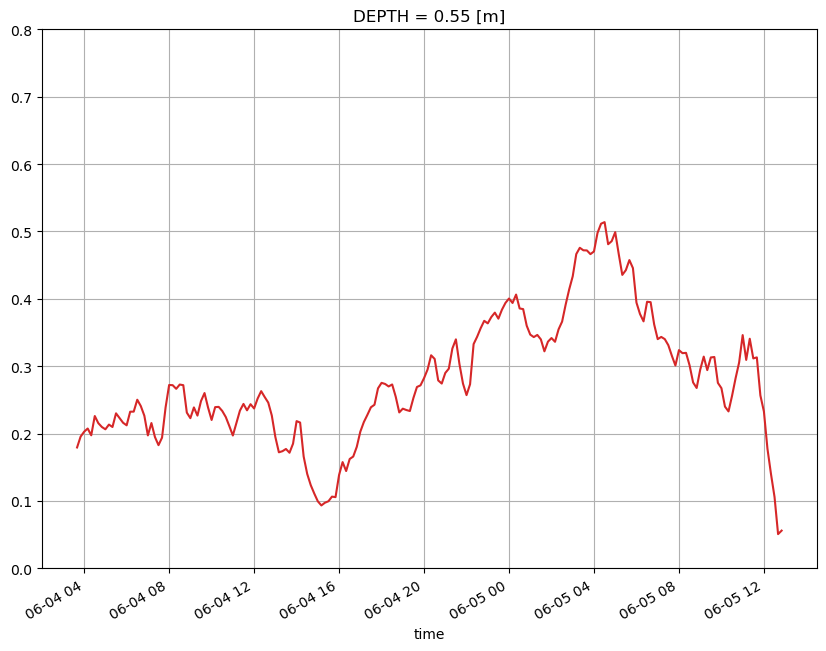

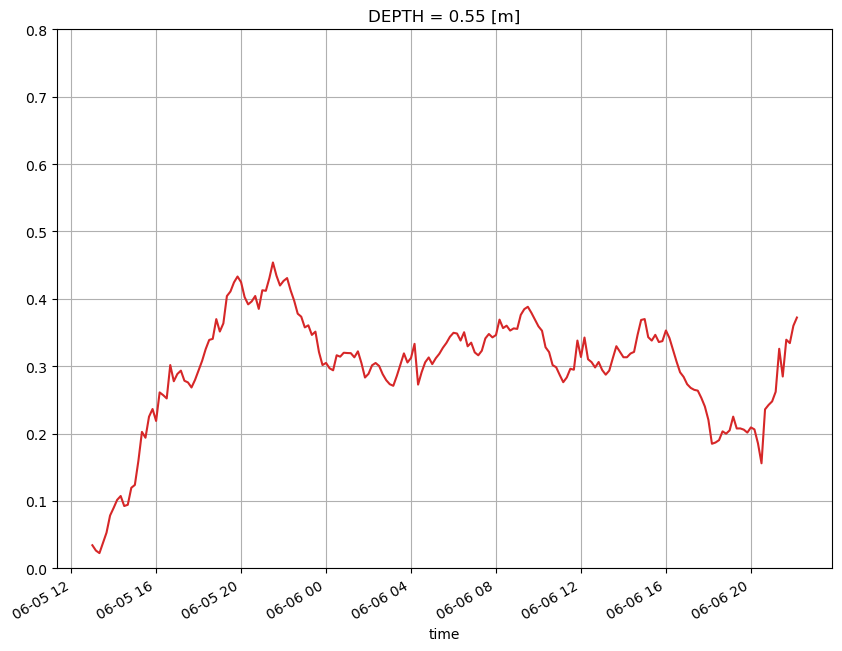

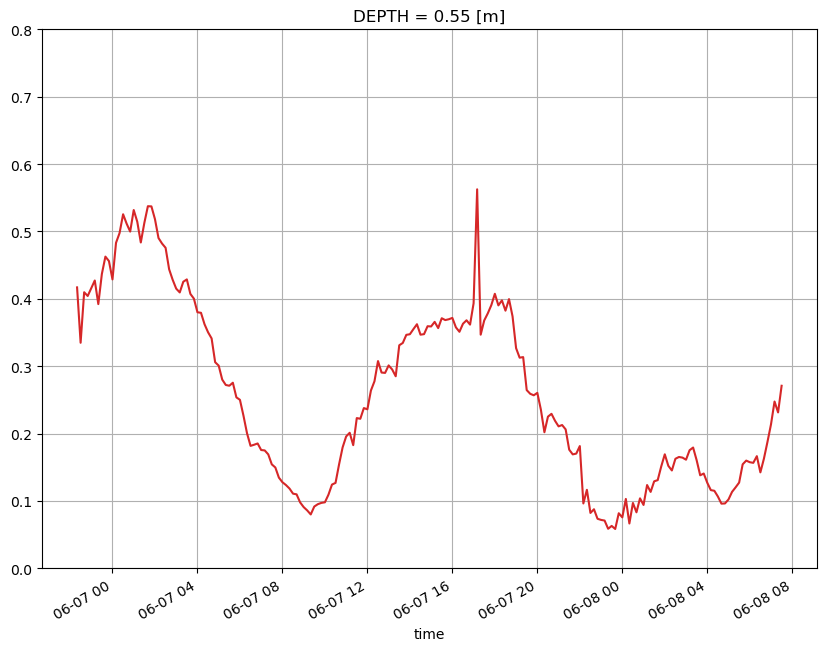

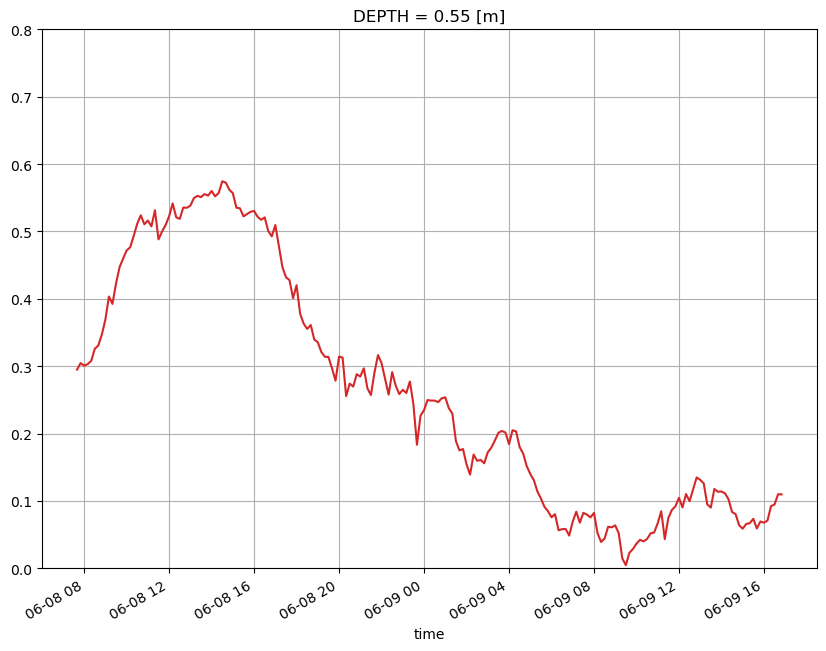

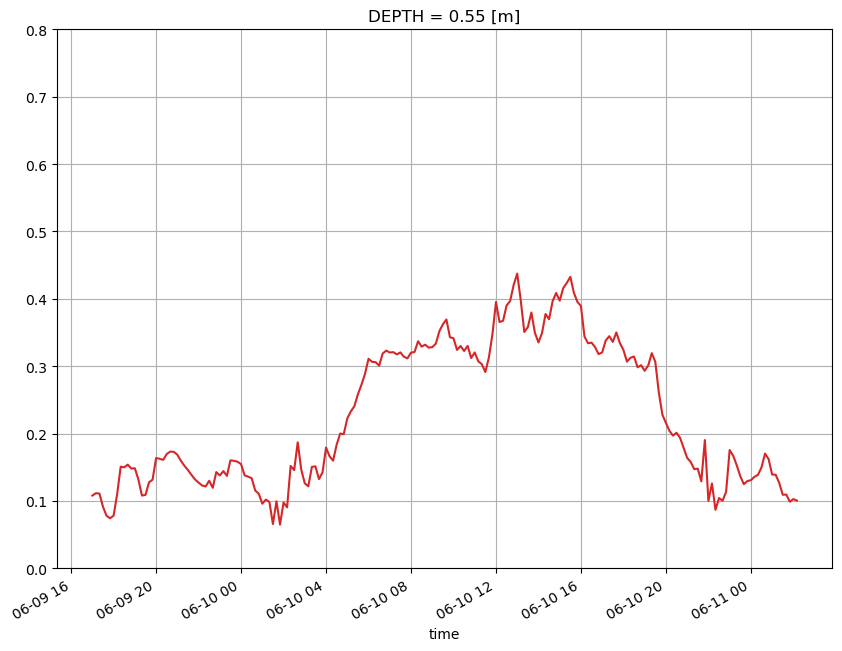

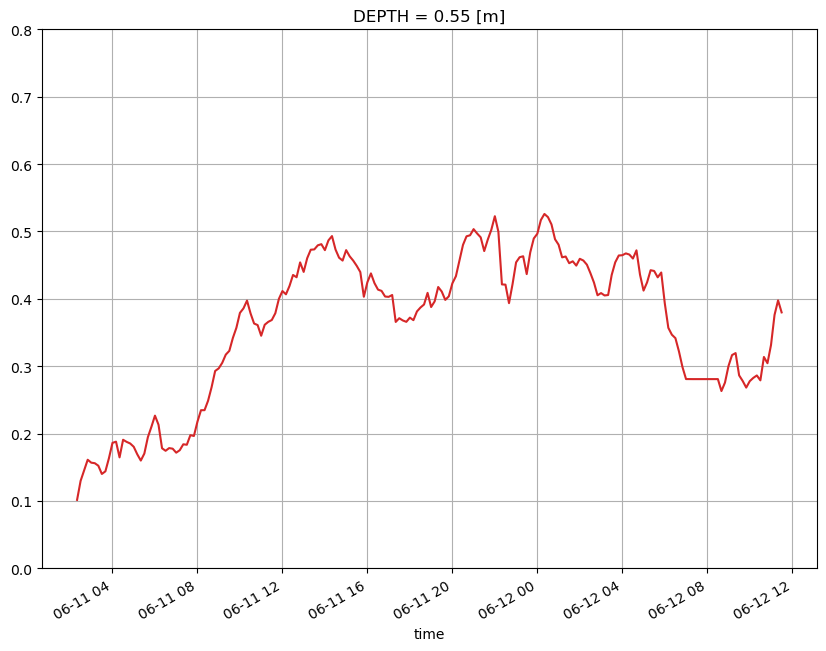

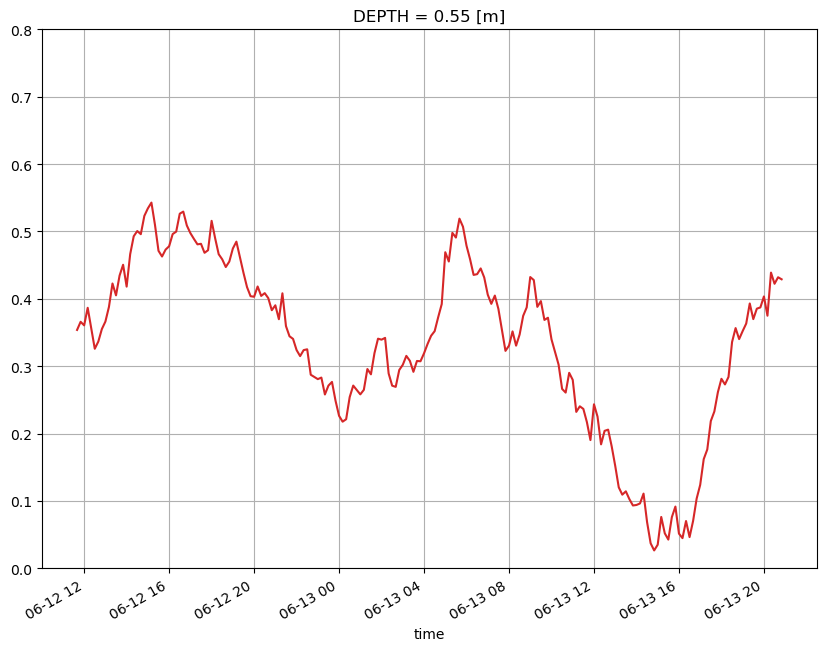

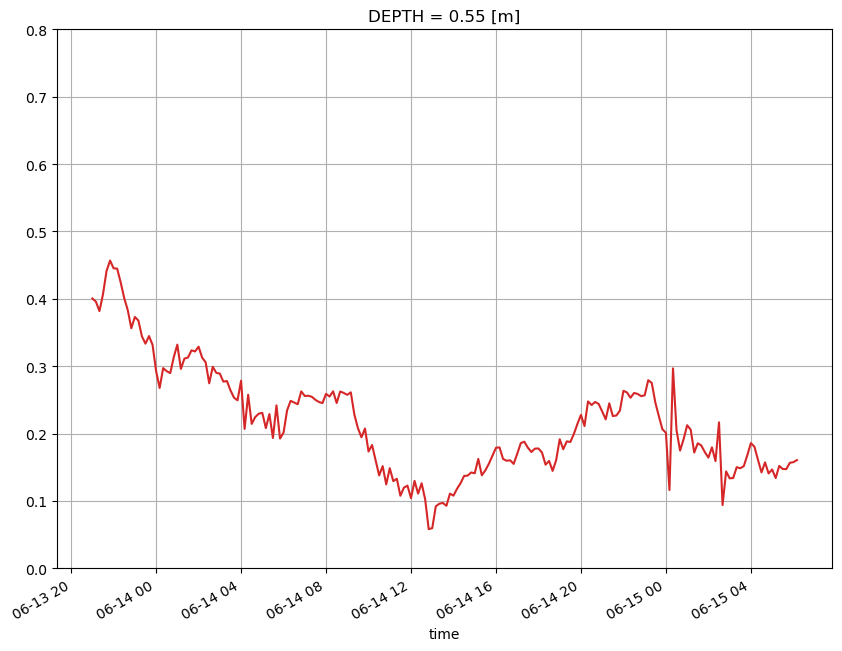

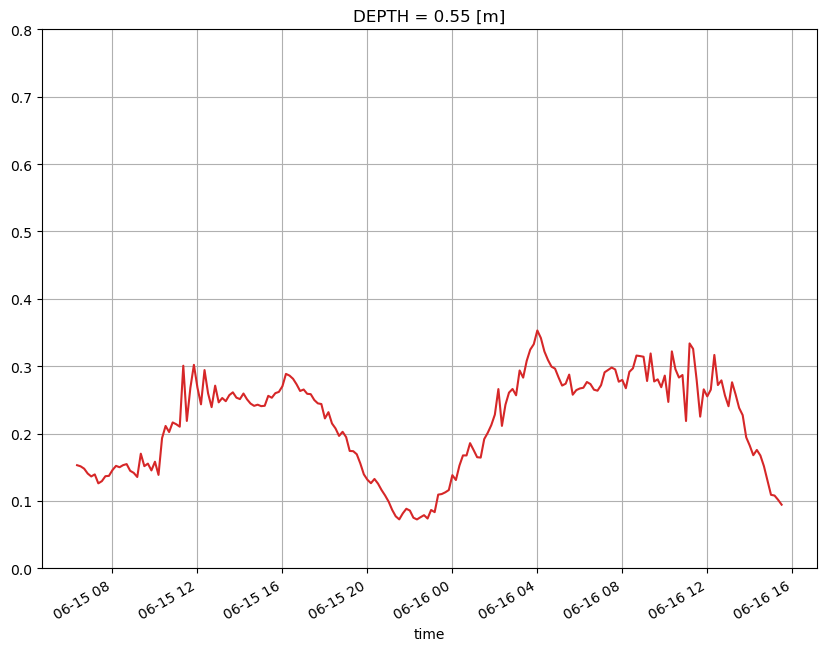

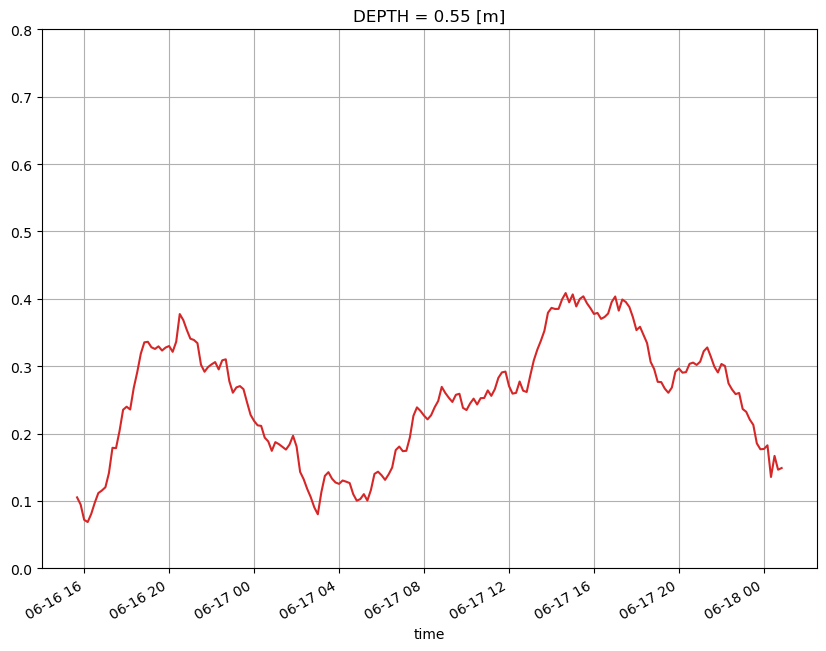

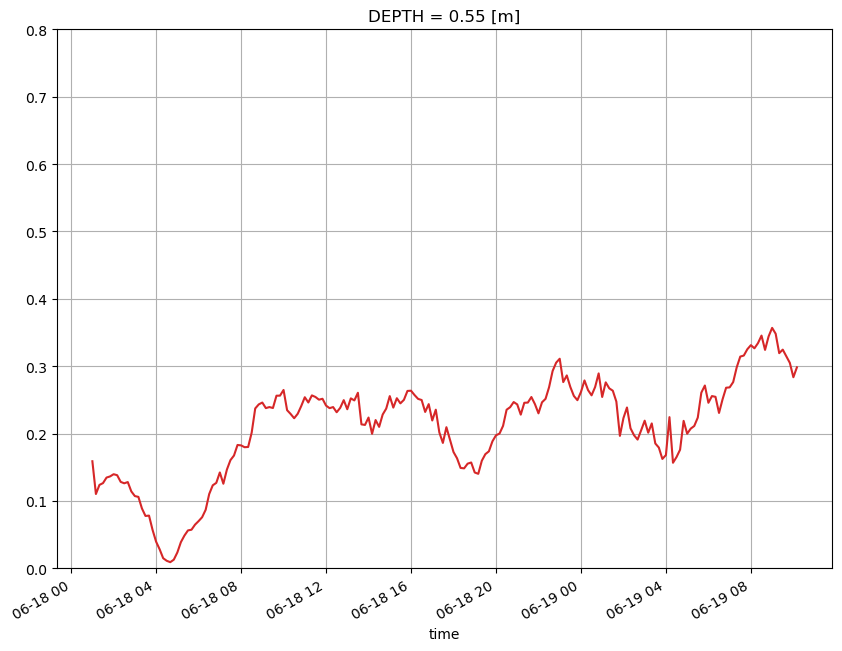

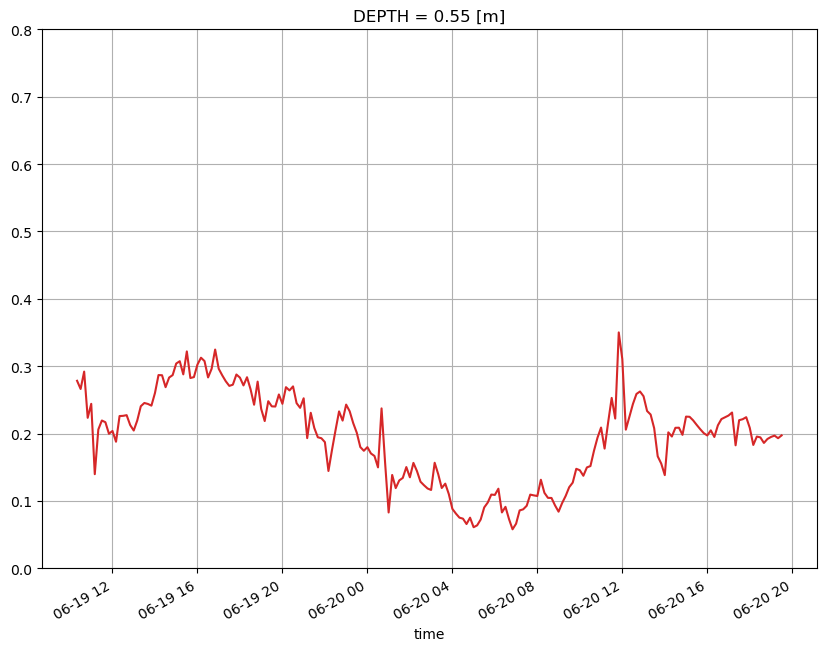

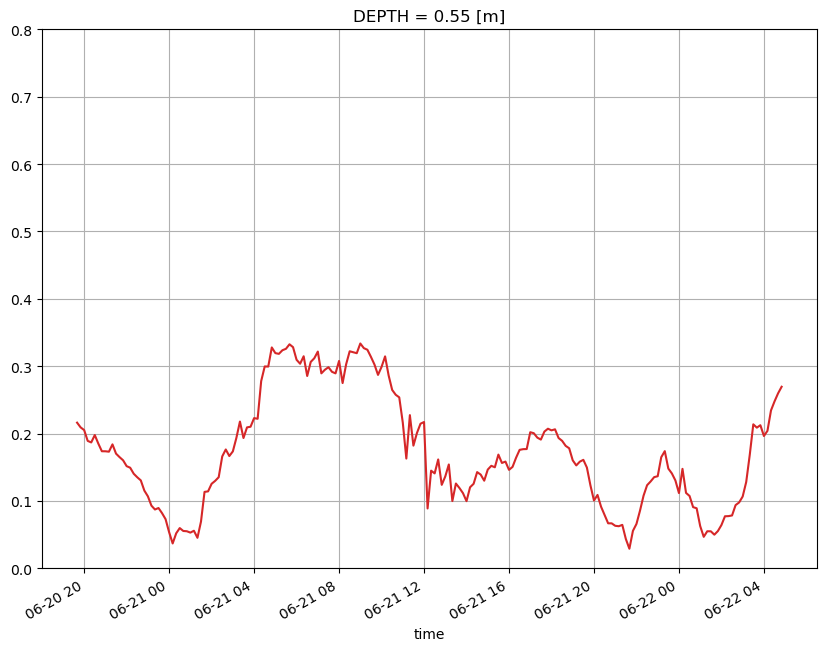

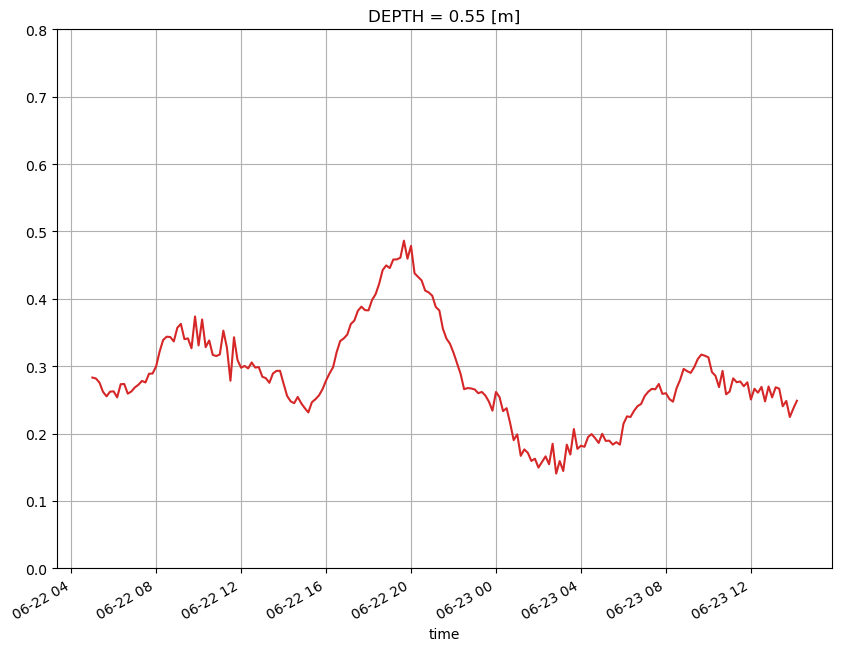

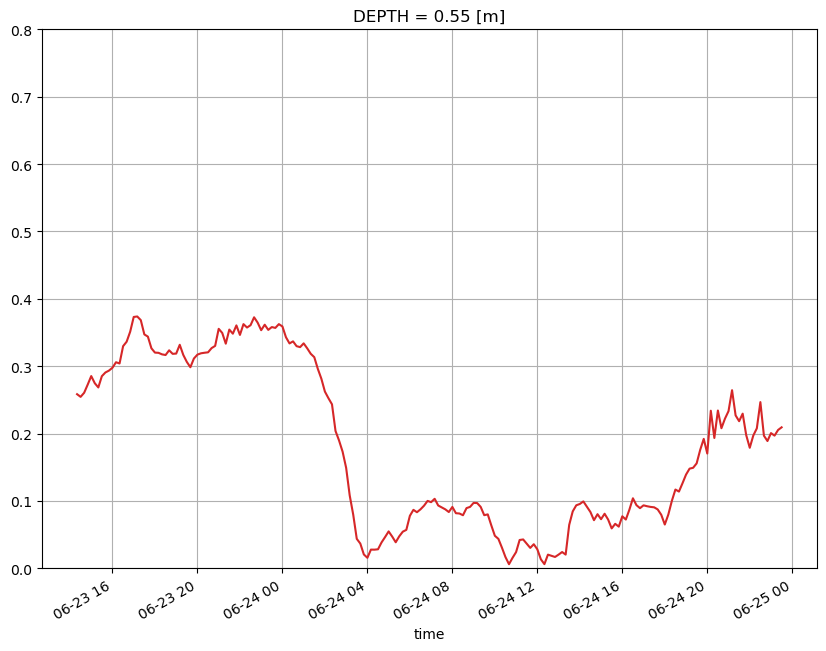

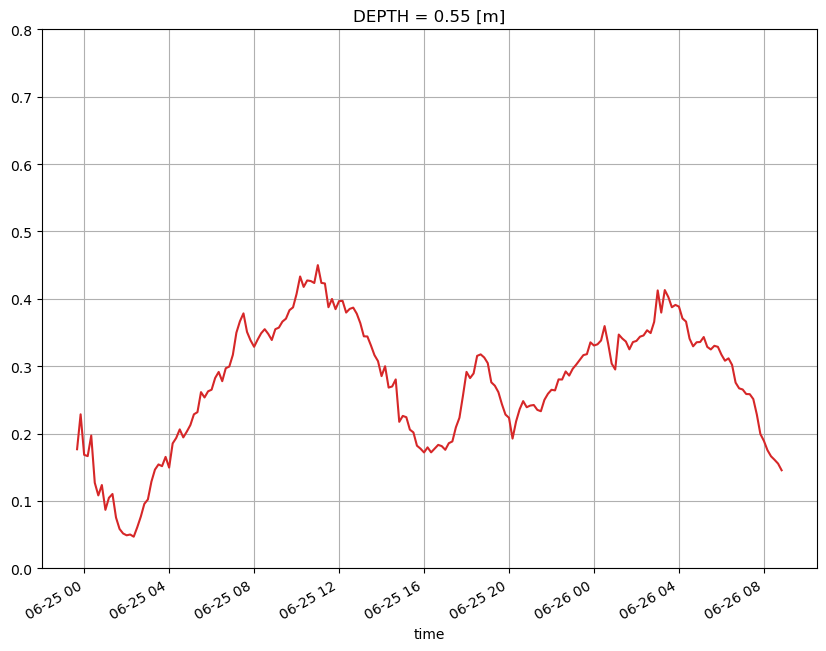

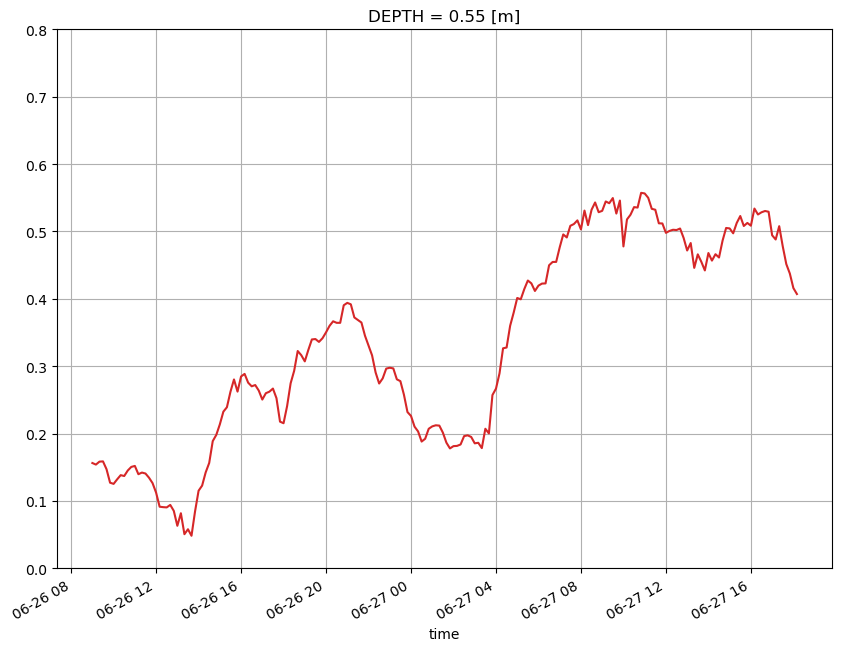

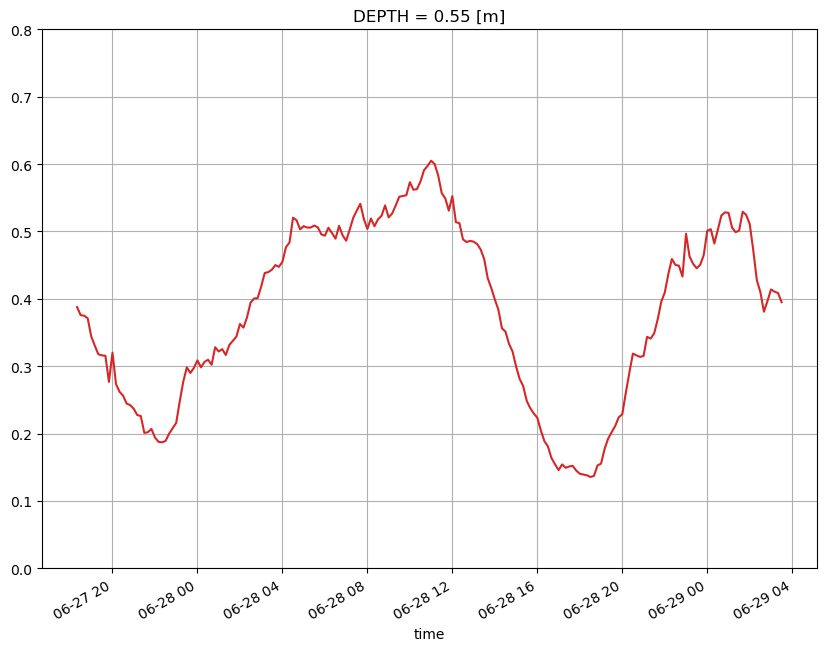

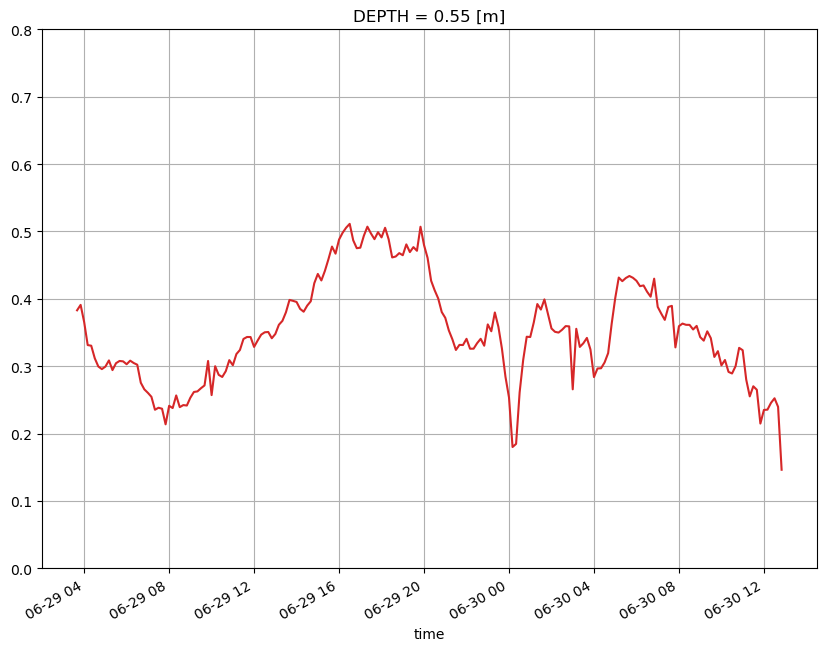

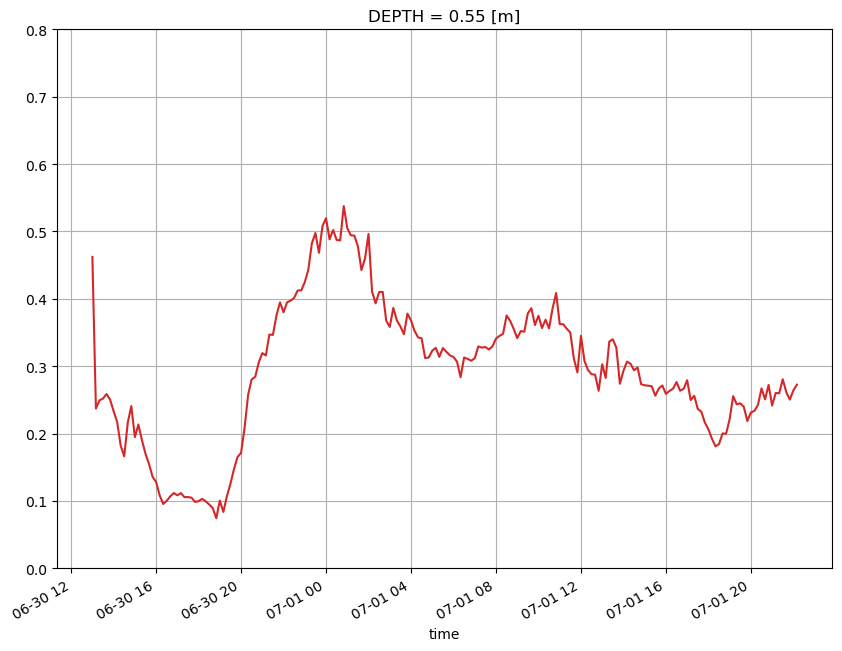

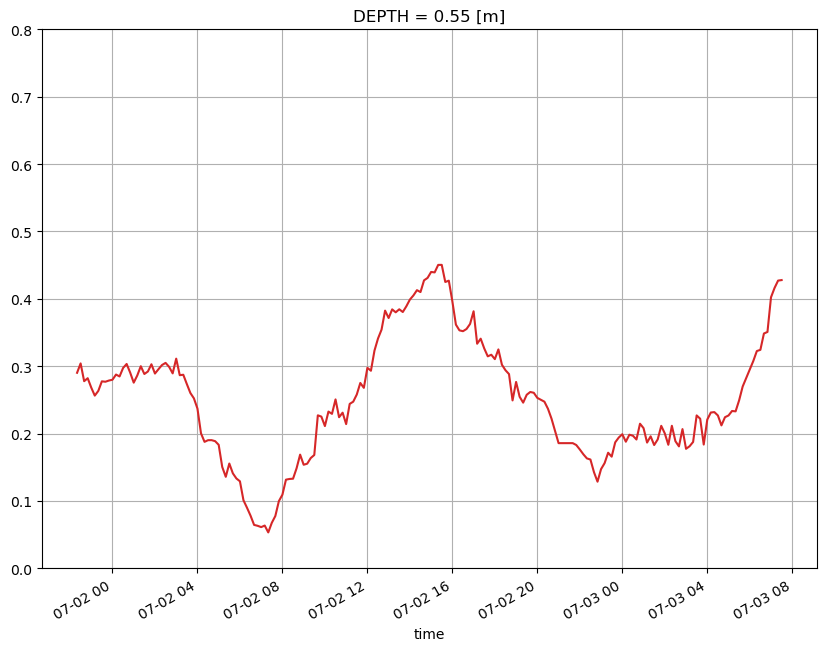

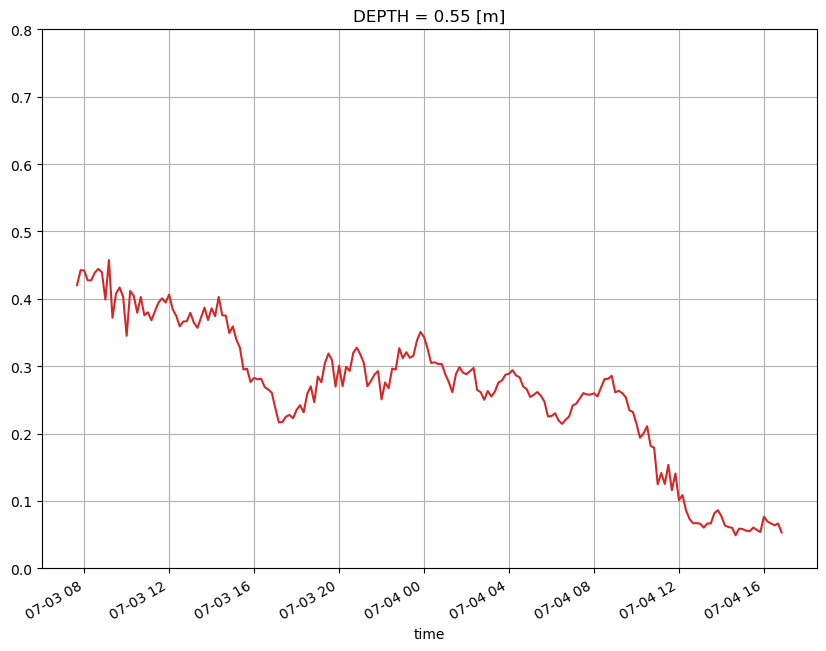

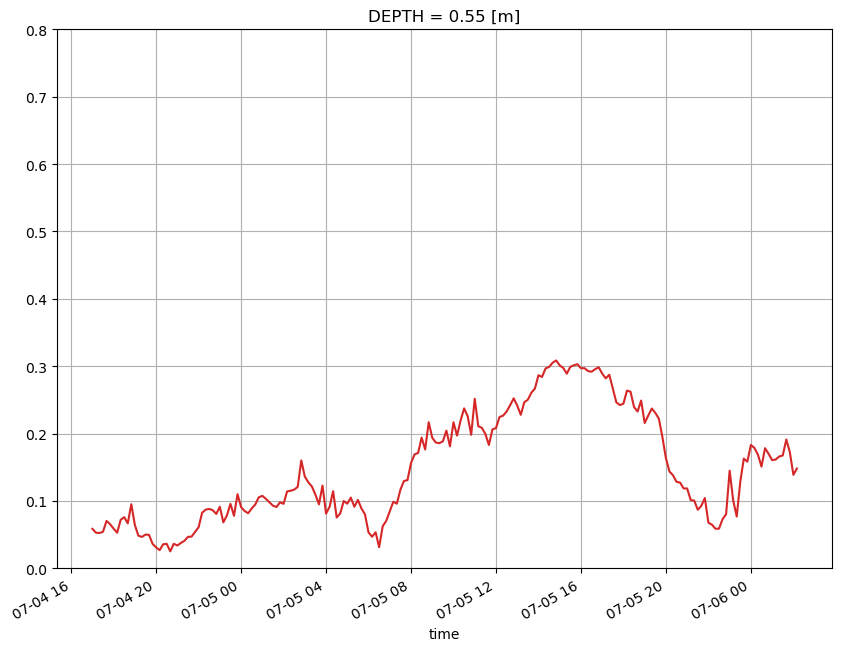

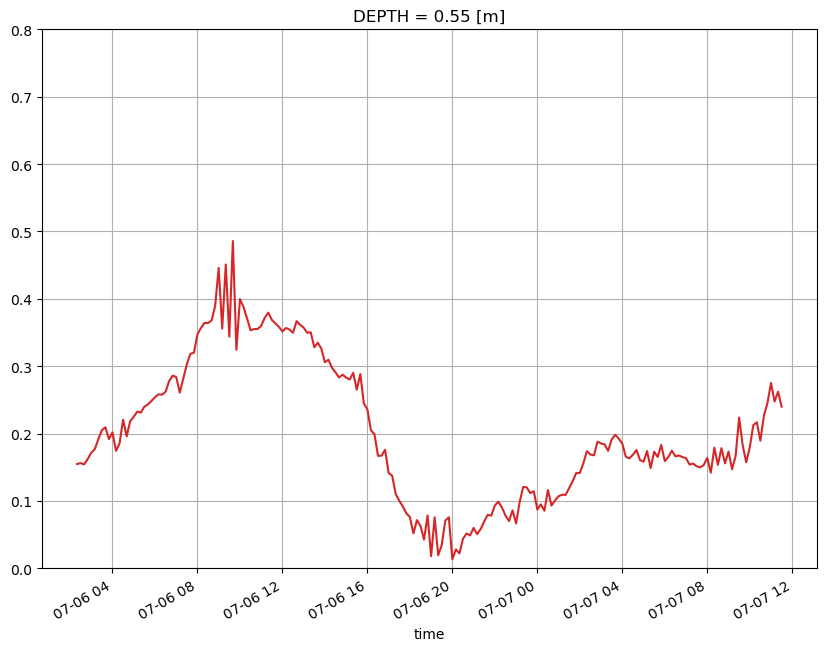

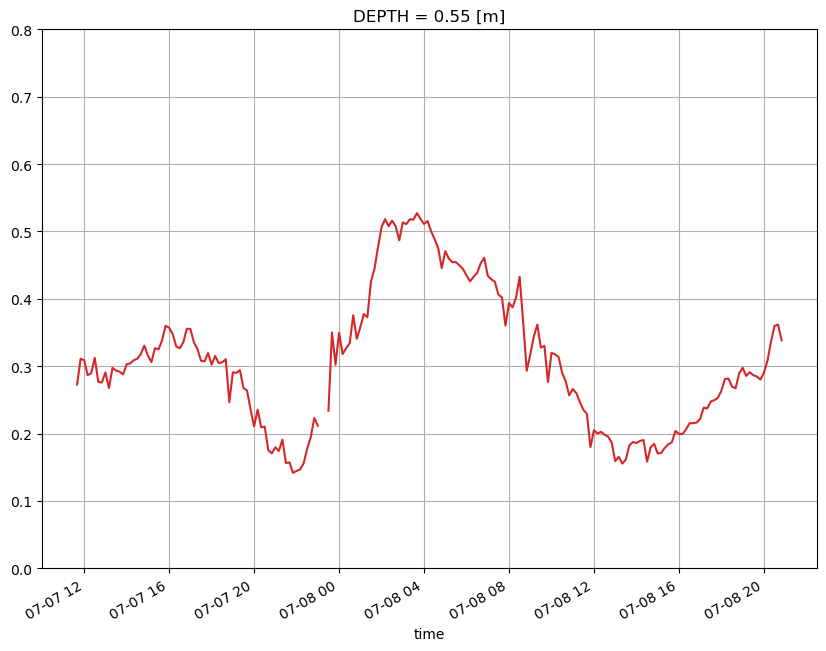

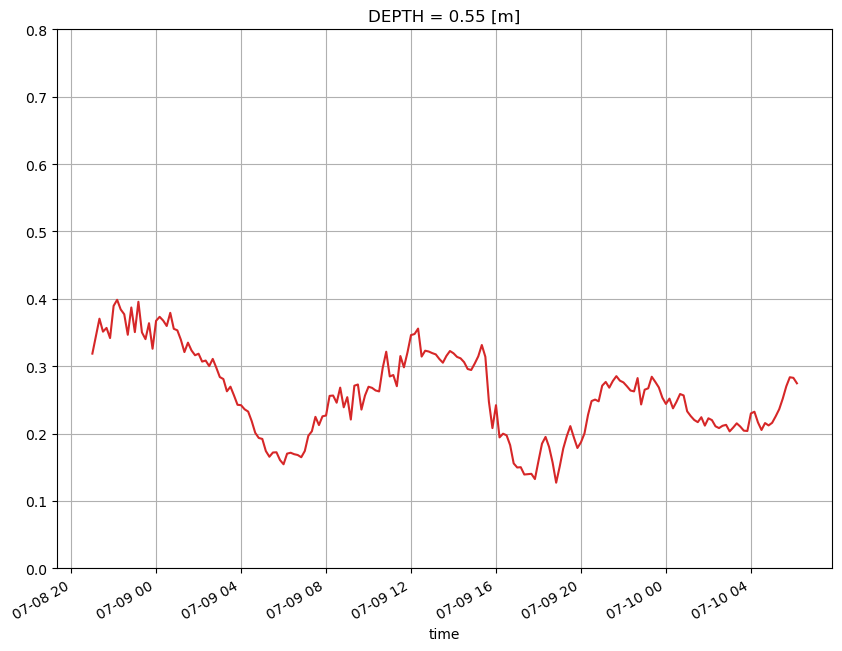

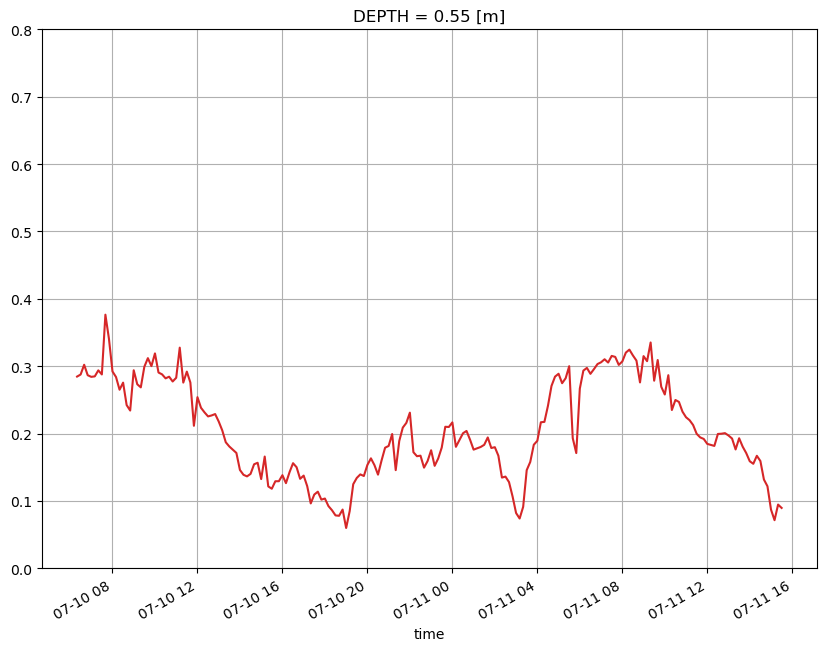

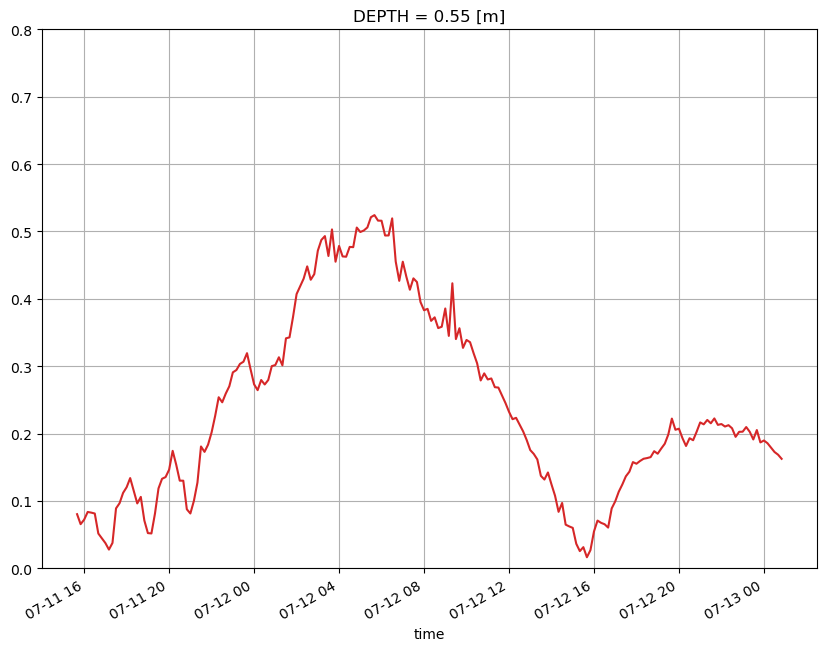

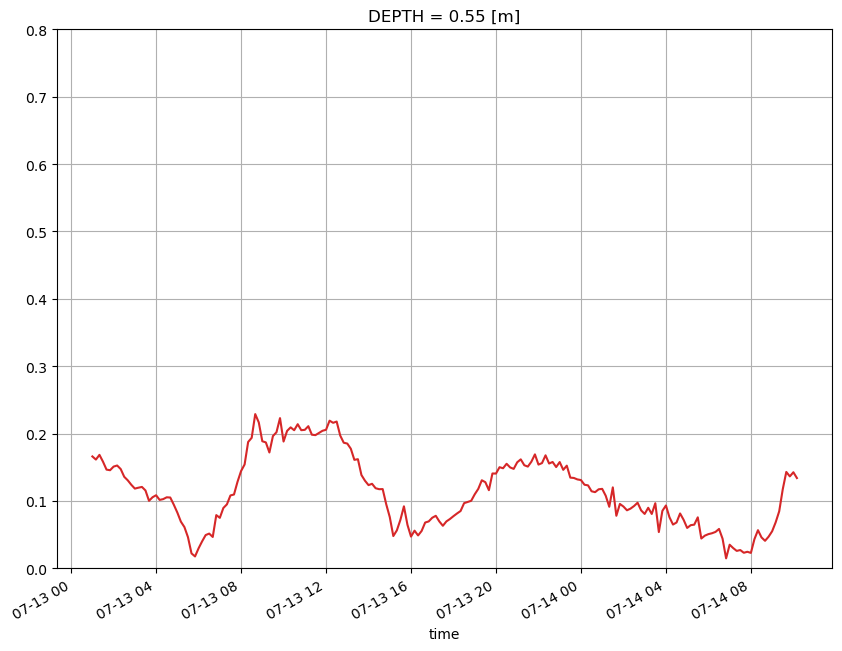

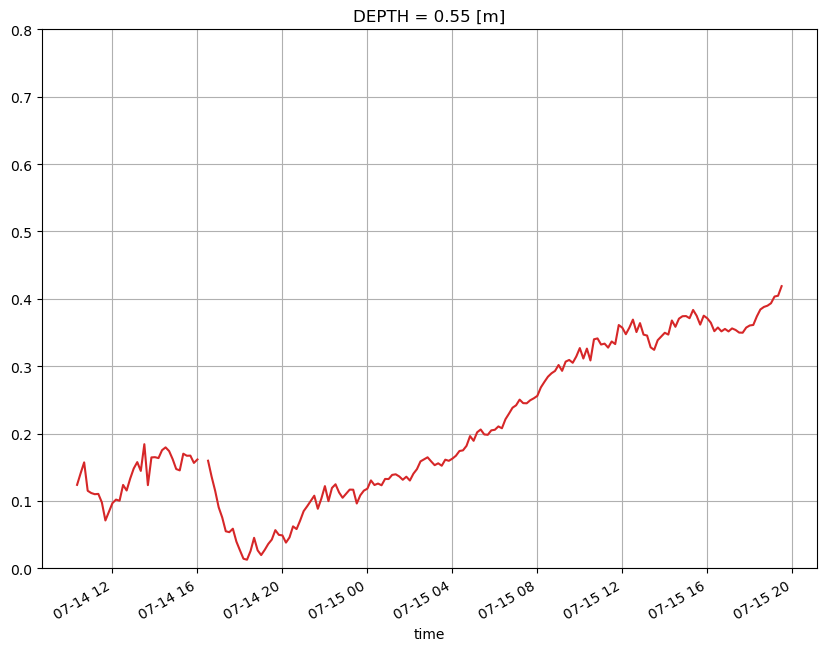

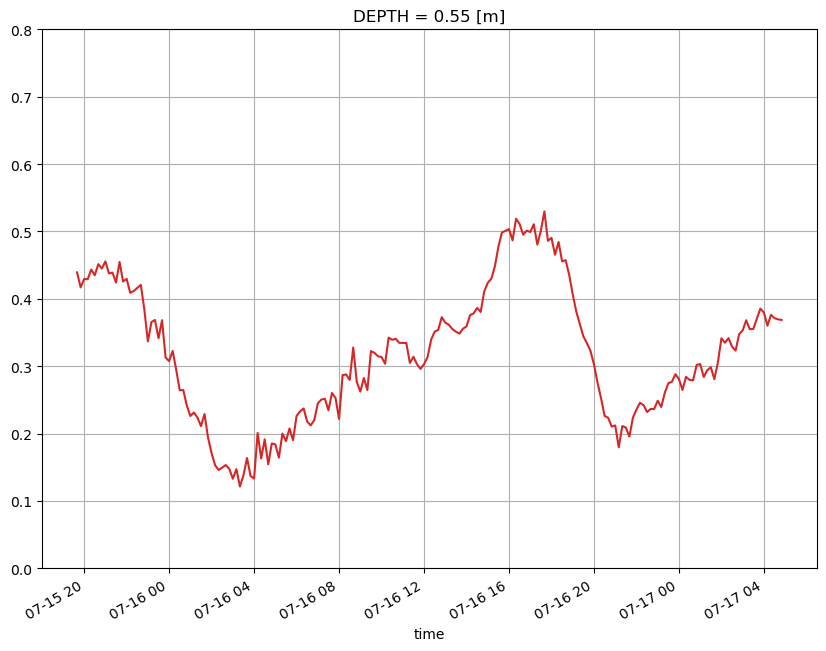

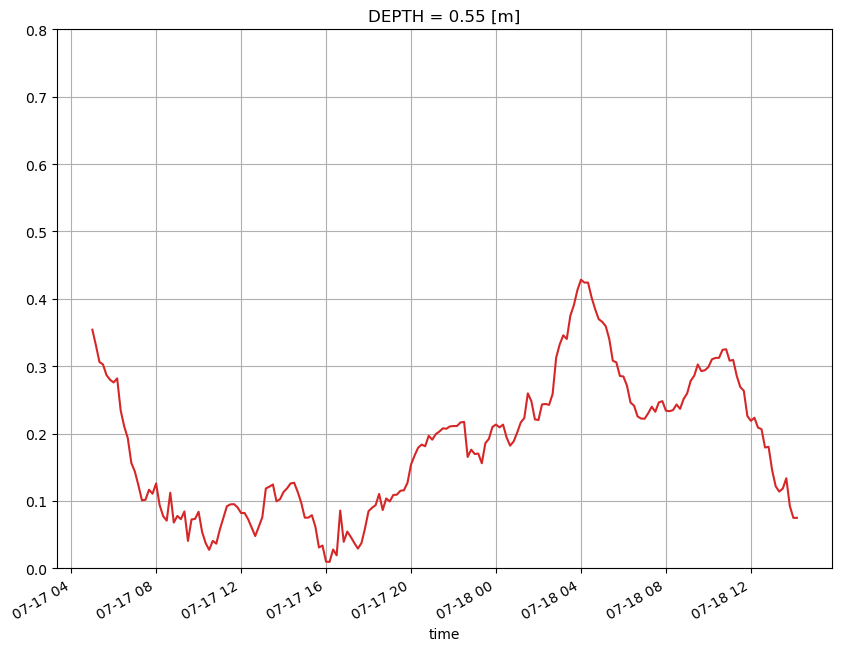

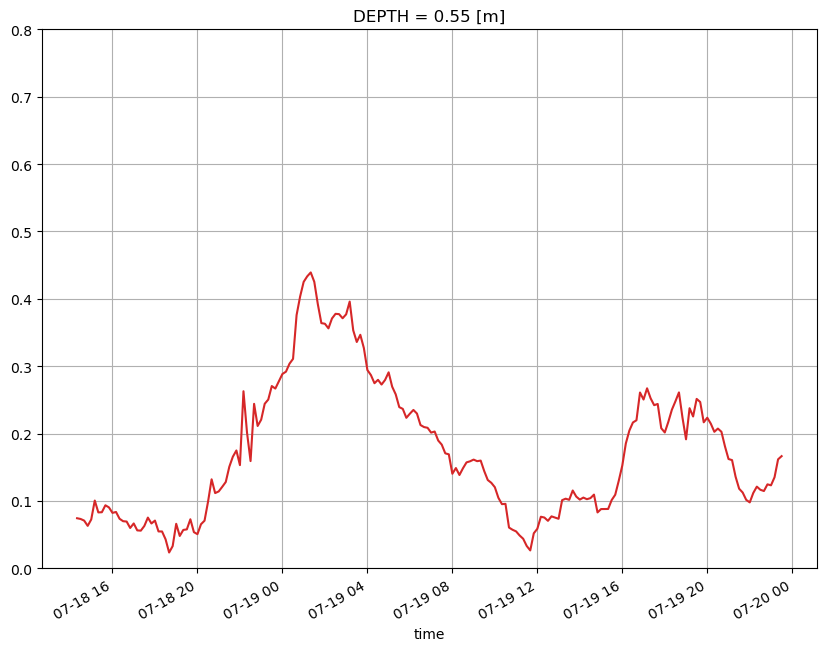

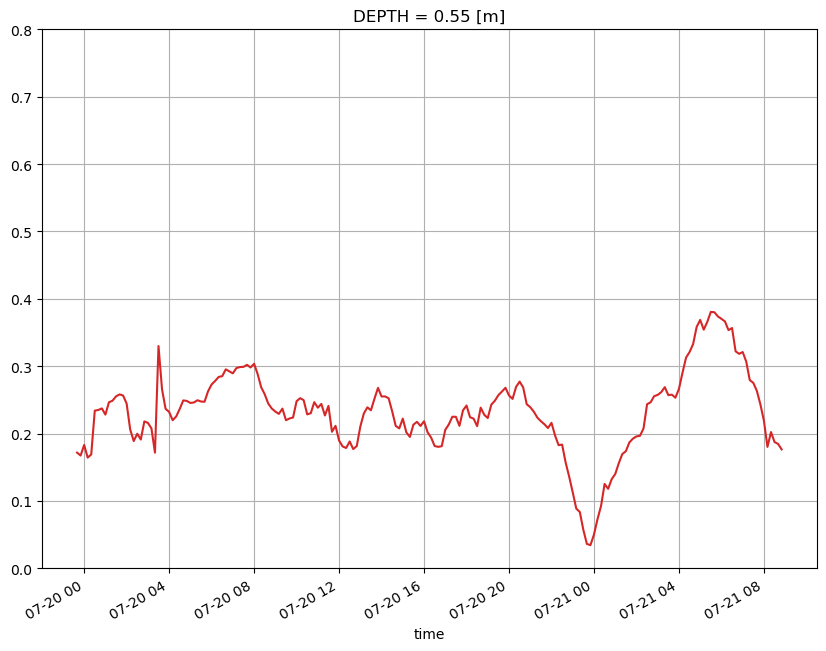

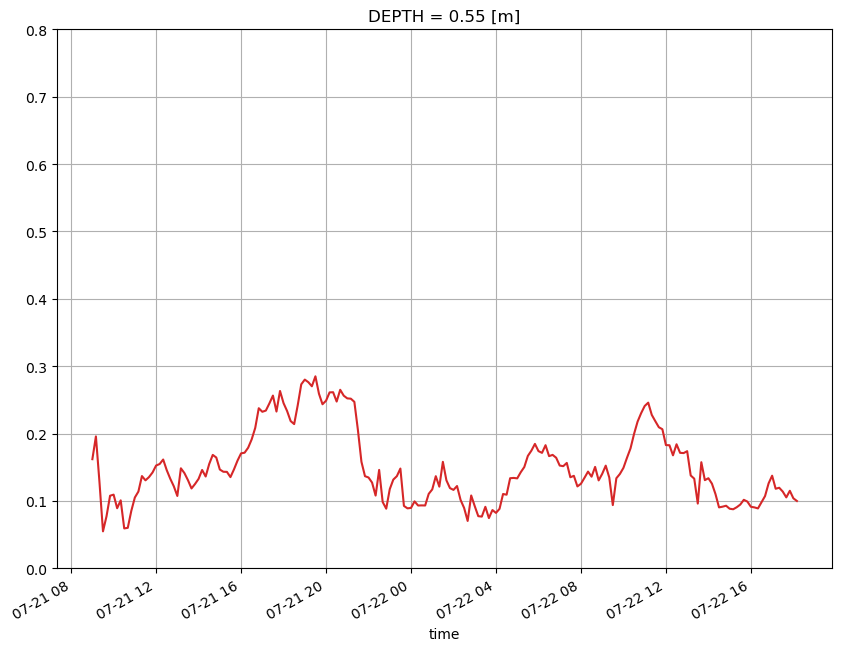

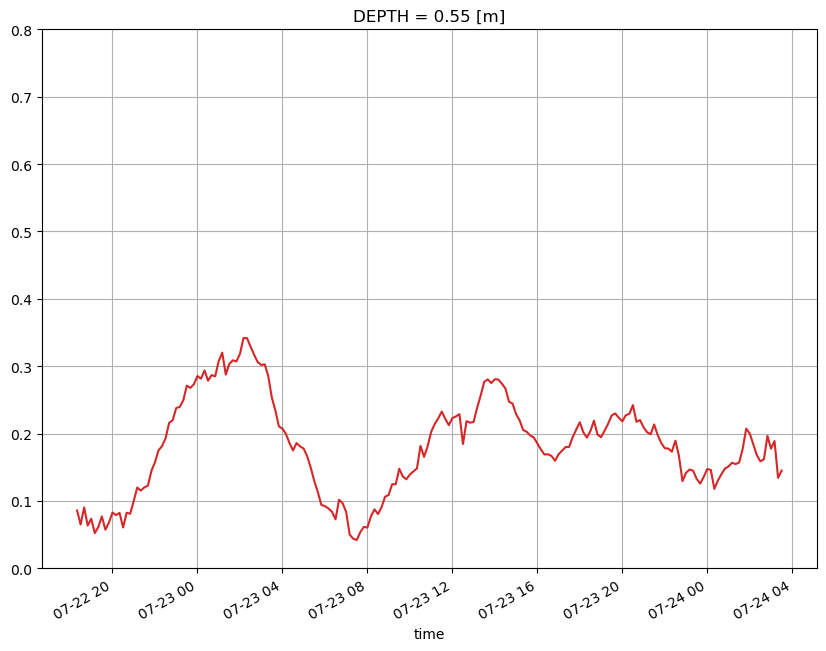

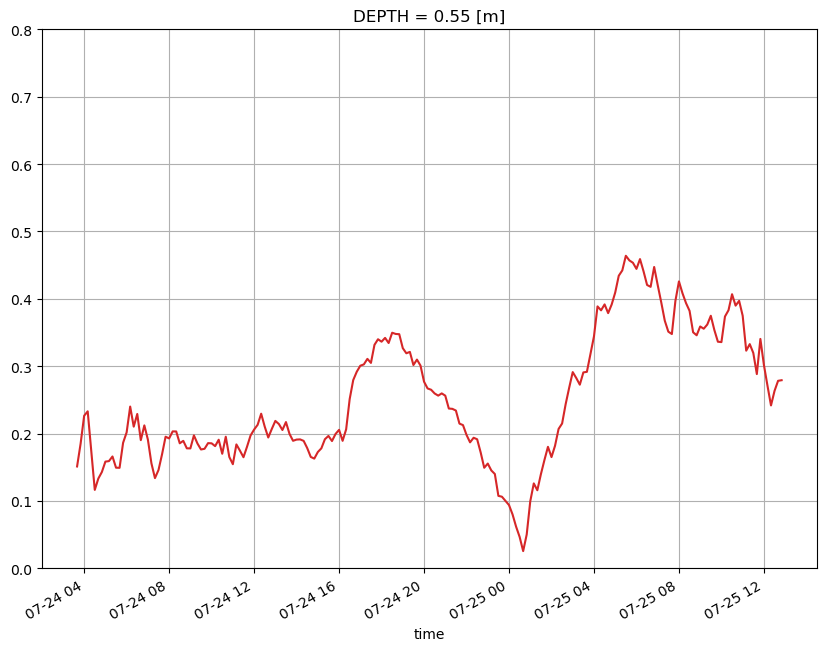

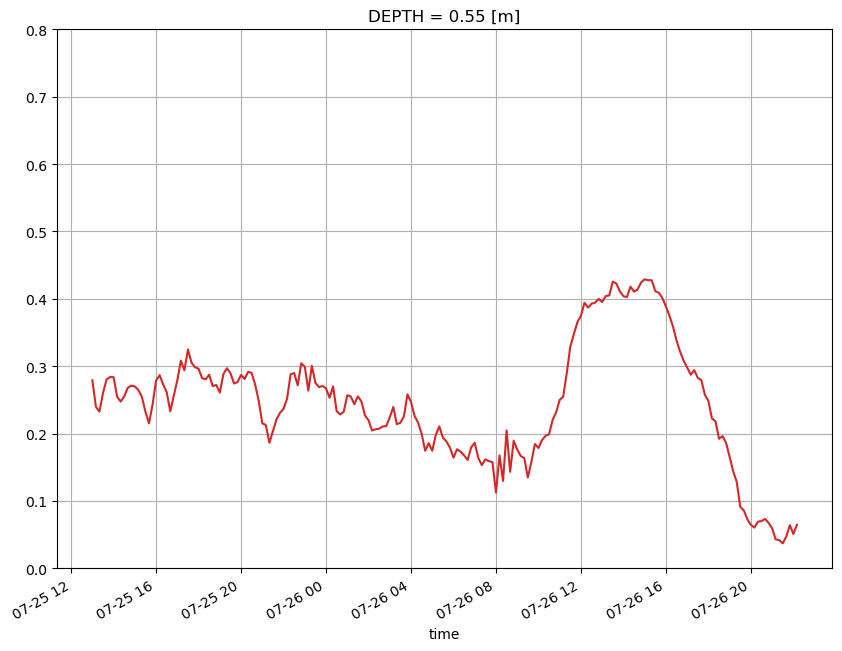

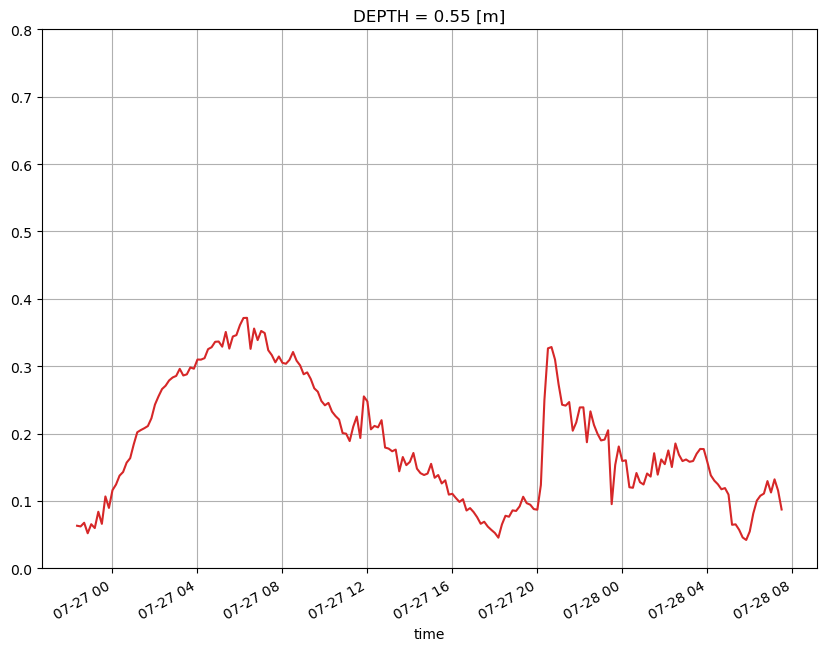

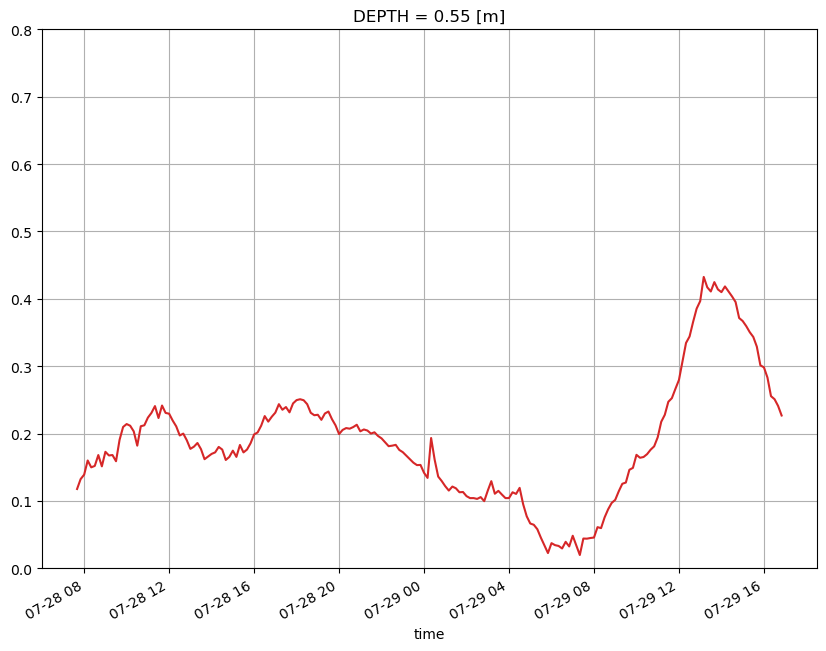

In [41]:
# to visualize data gaps:
for ii in range(0, int(np.floor(len(abs_vel_thres)/200.))):
    abs_vel_thres[(ii*200):((ii+1)*200)].plot(figsize=(10,7), c='C3')
    plt.ylim([0,0.8])
    plt.grid()

### 2.4.2. Smaller spike removal

We will use a moving threshold based on the standard deviation of the window. Values of speed outside this threshold will be marked as spikes

In [42]:
# Number of points of the window
window_data = 12

In [43]:
# Obtain the moving std
speed_std = abs_vel_thres.rolling(time=window_data, center=True).std()
speed_median = abs_vel_thres.rolling(time=window_data, center=True).median()
#speed_std = speed_median.rolling(time=int(window_data/2), center=True).std()

In [44]:
# Overview
import matplotlib.dates as mdates
dates = mdates.date2num(ds02['time'])
dates

array([19487.15277778, 19487.15972222, 19487.16666667, ...,
       19568.51388889, 19568.52083333, 19568.52777778])

/var/folders/54/mb8qg4_j53d9_q2jnv7n8sjc0000gn/T/ipykernel_6998/1748048721.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,4))


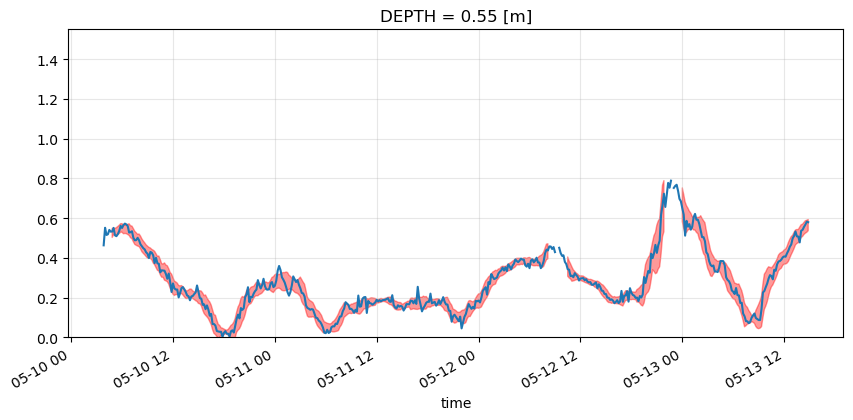

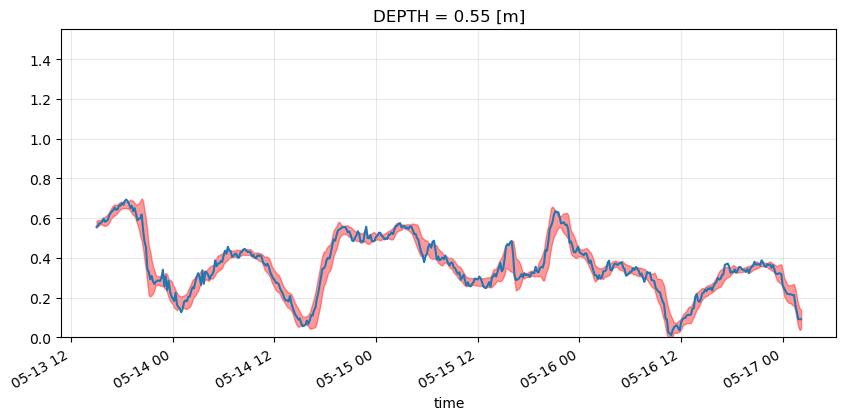

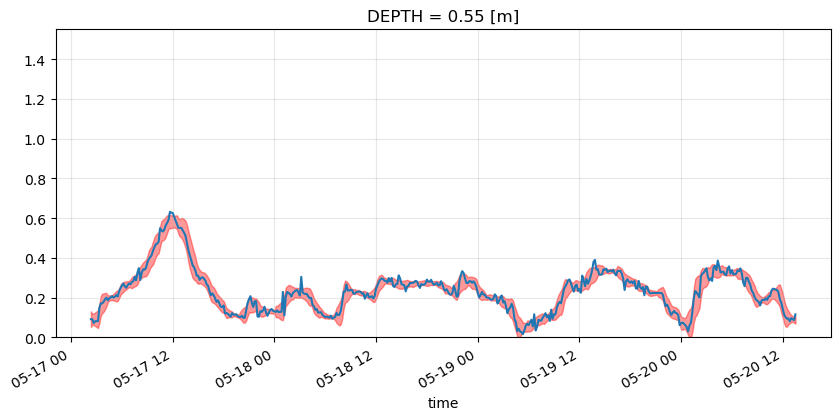

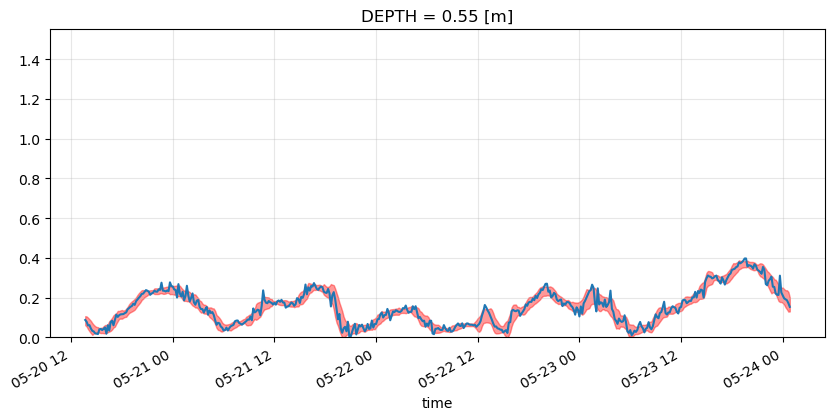

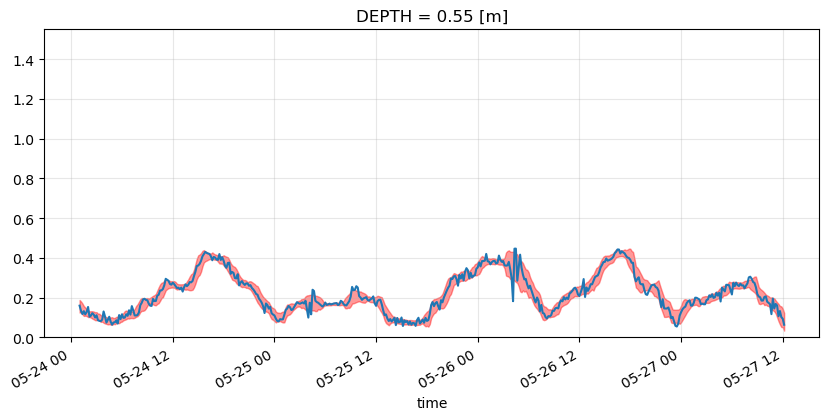

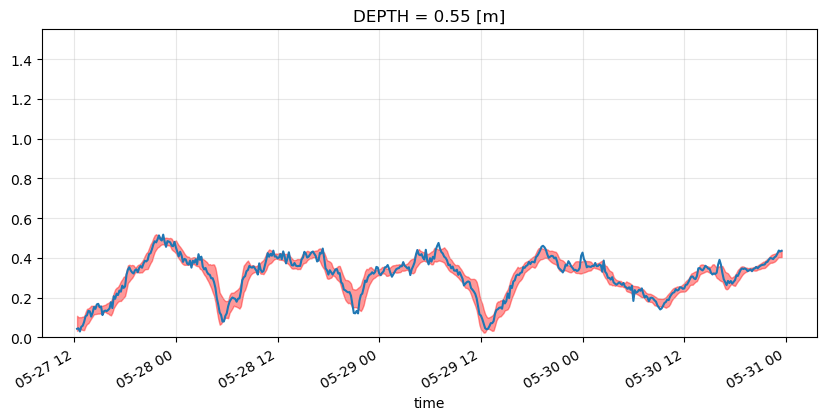

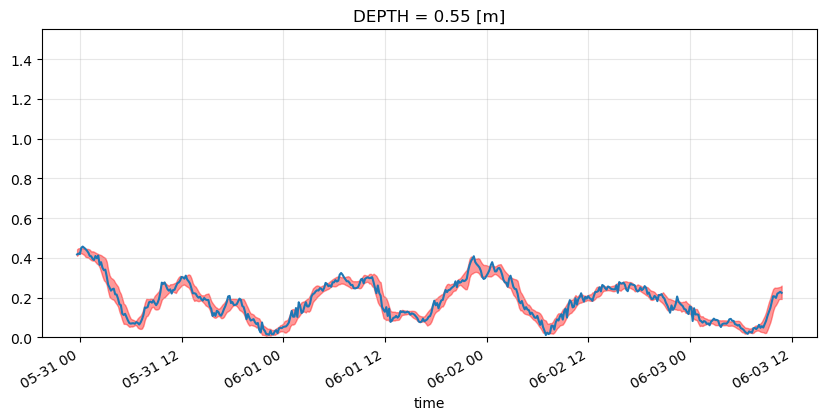

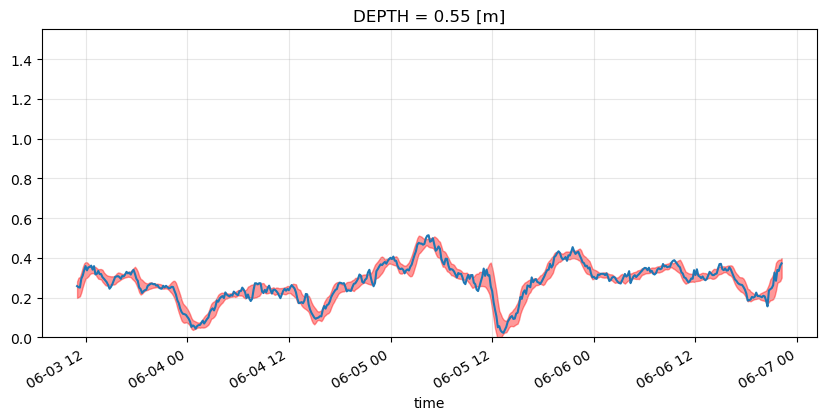

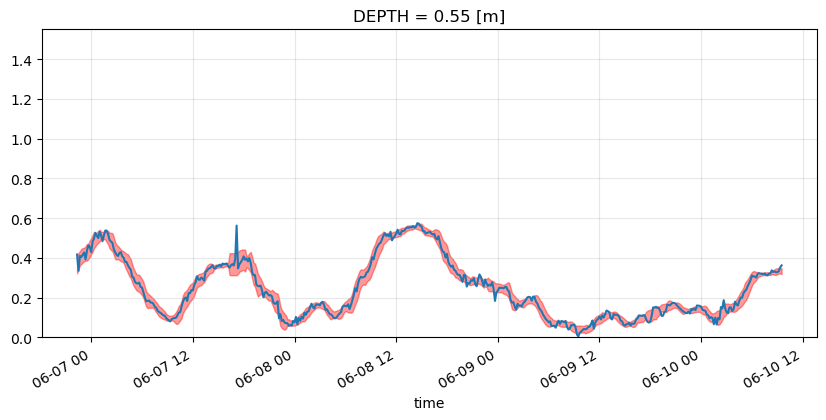

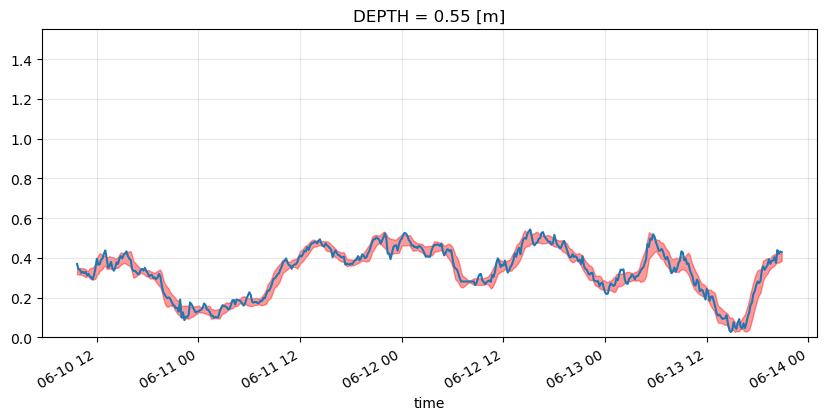

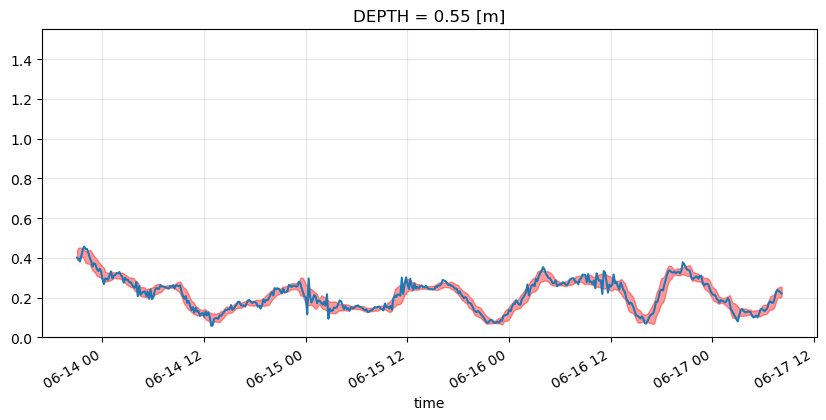

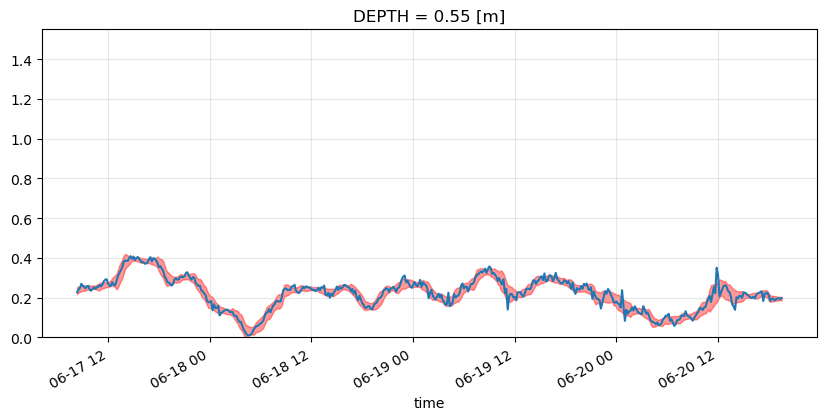

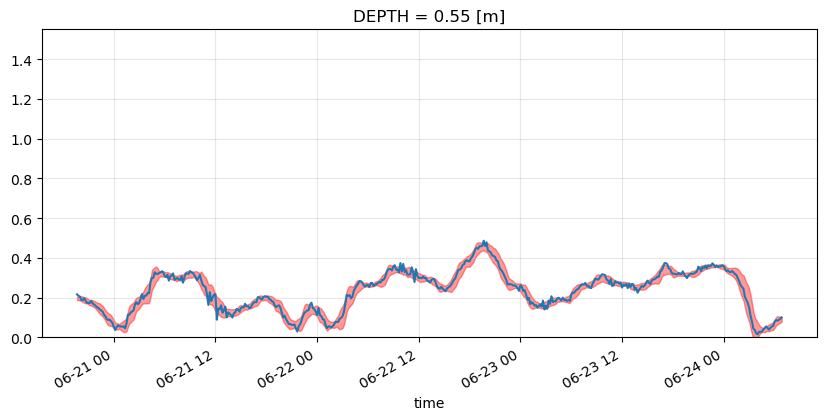

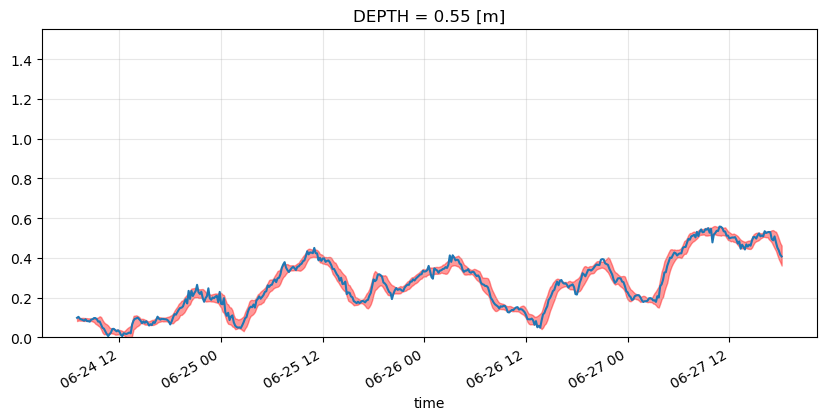

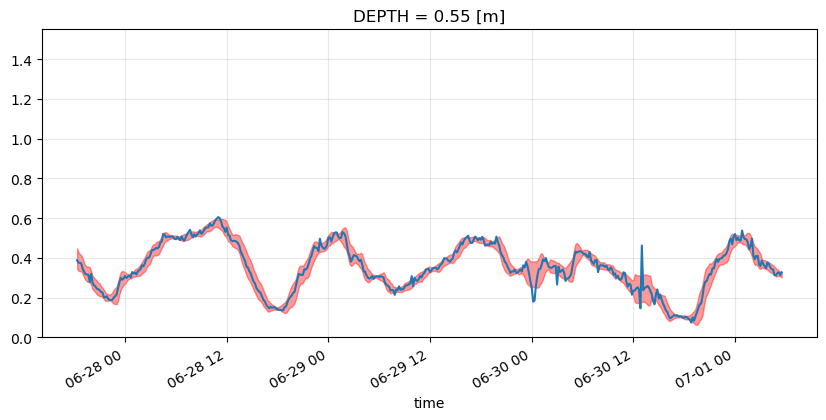

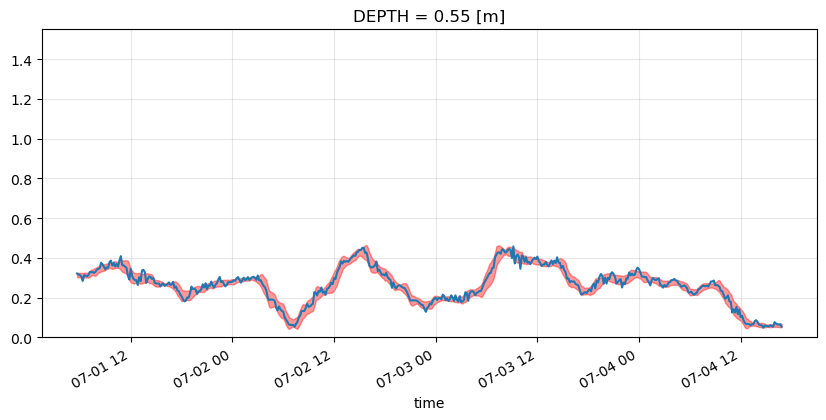

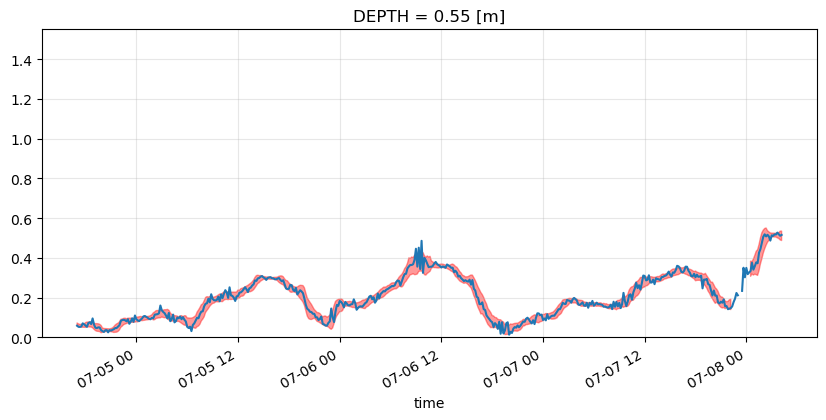

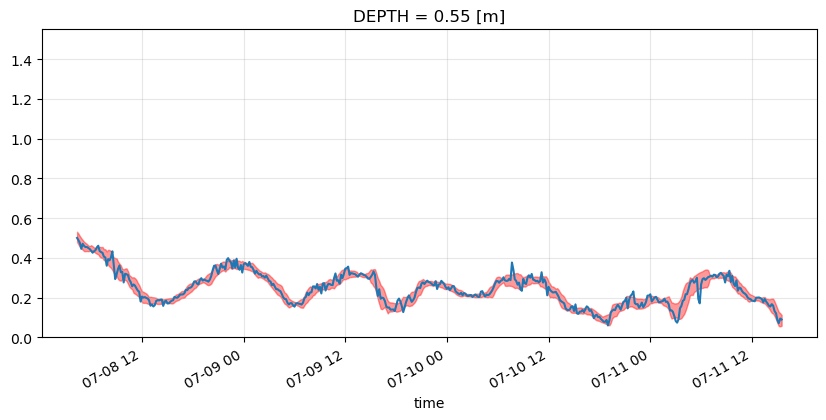

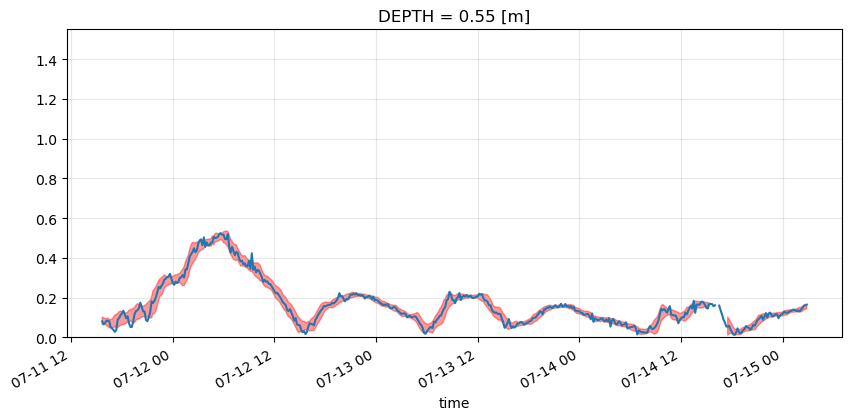

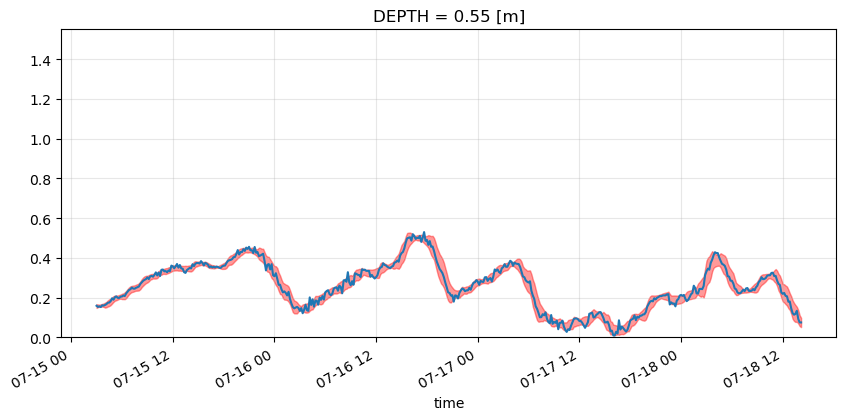

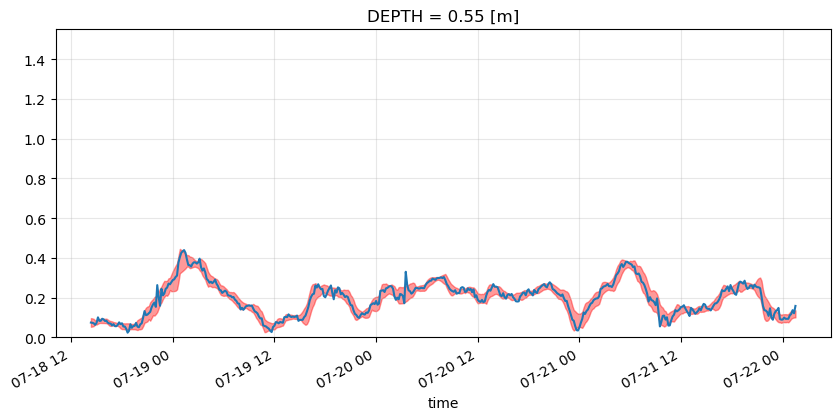

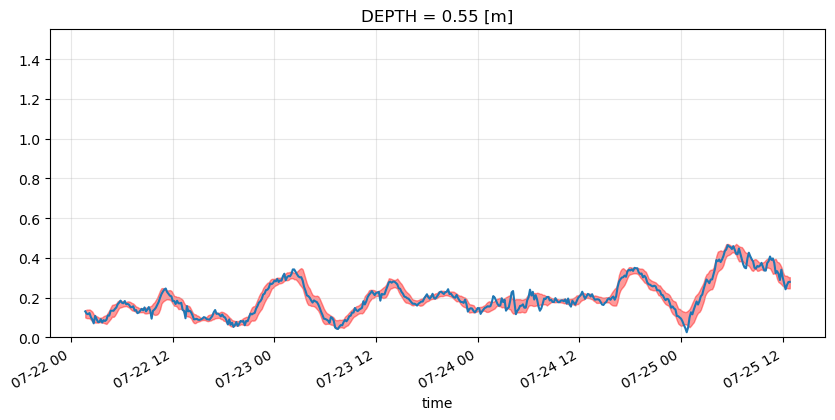

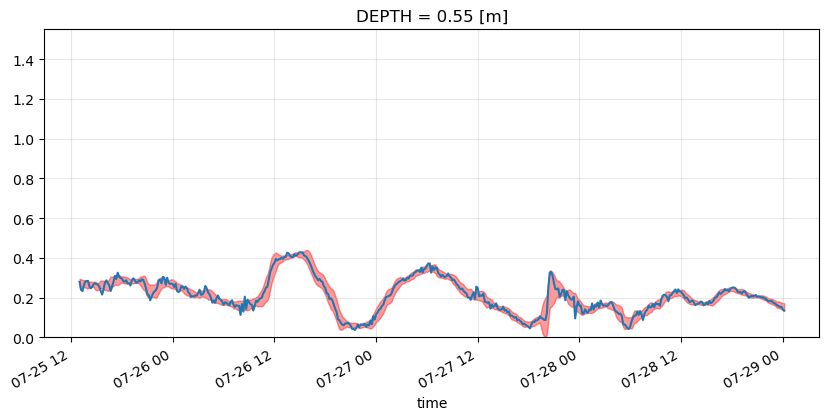

In [45]:
# Zoomed subsamples
tt = 500
for ii in range(0, int(np.floor(len(abs_vel)/tt))):
    plt.figure(figsize=(10,4))
    x = dates[(ii*tt):((ii+1)*tt)]
    y = speed_median[(ii*tt):((ii+1)*tt)]
    std_zoom = speed_std[(ii*tt):((ii+1)*tt)]
    plt.fill_between(x=x, y1=y-std_zoom, y2=y+std_zoom,color='r',alpha=0.4)
    abs_vel_thres[(ii*tt):((ii+1)*tt)].plot()
    plt.ylim([0,1.55])
    plt.grid(alpha=0.3)

In [46]:
# Set limits for spike cleaning
upper_limit = speed_median + speed_std
bottom_limit = speed_median - speed_std

In [47]:
ds04 = ds03.where((abs_vel_thres < upper_limit) & (abs_vel_thres > bottom_limit))

Zonal component:

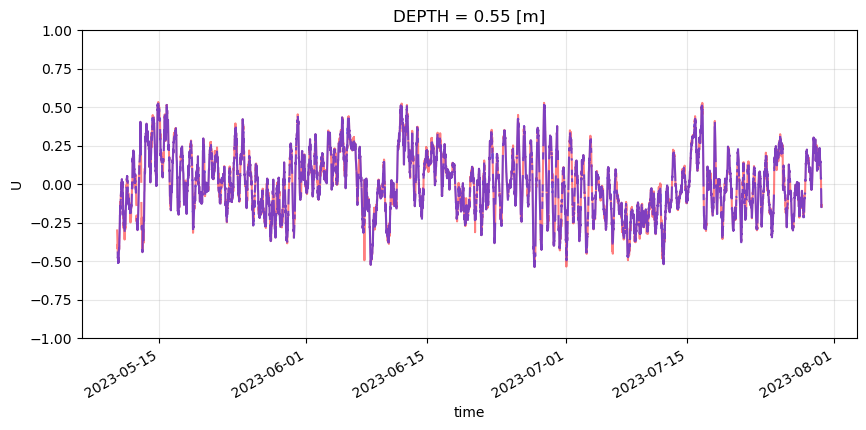

In [48]:
plt.figure(figsize=(10,4))
ds03.U.plot(alpha = 0.5, color = "red", label='old');
ds04.U.plot(alpha = 0.5, color = "blue", label='new');
plt.ylim(-1,1)
plt.grid(alpha=0.3)

Meridional component:

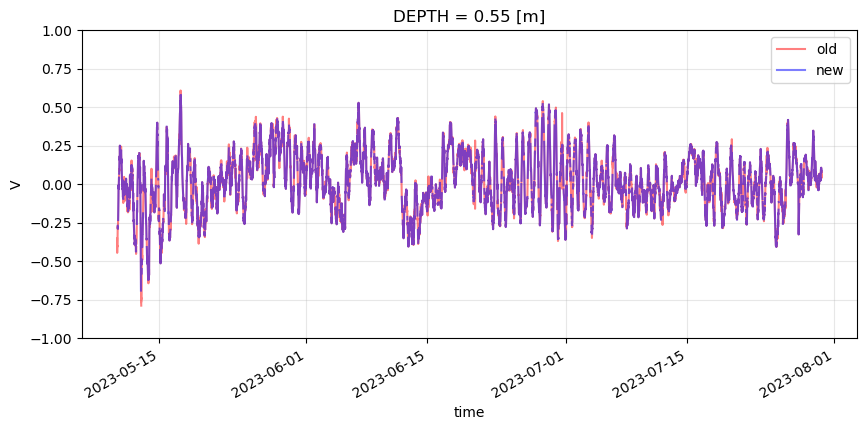

In [49]:
plt.figure(figsize=(10,4))
ds03.V.plot(alpha = 0.5, color = "red", label='old');
ds04.V.plot(alpha = 0.5, color = "blue", label='new');
plt.ylim(-1,1)
plt.grid(alpha=0.3)
plt.legend()

## 2.5. Smoothing

### 2.5.1. Interpolation
(again to fill in spike gaps, smoothing method applied (for now) next does not fill in the gaps) --> to check

In [50]:
# To apply interpolate, we need to remove the trajectory variable because it is a string not a float (number)
ds05 = ds04.drop_vars("trajectory") # trajectory variable unnecessary, check with Lara --> not better attrubte?

In [51]:
ds05 = ds05.interpolate_na(dim='time', method="pchip") 
# Pchip : cubic with splines interp. (Dani find ref.)

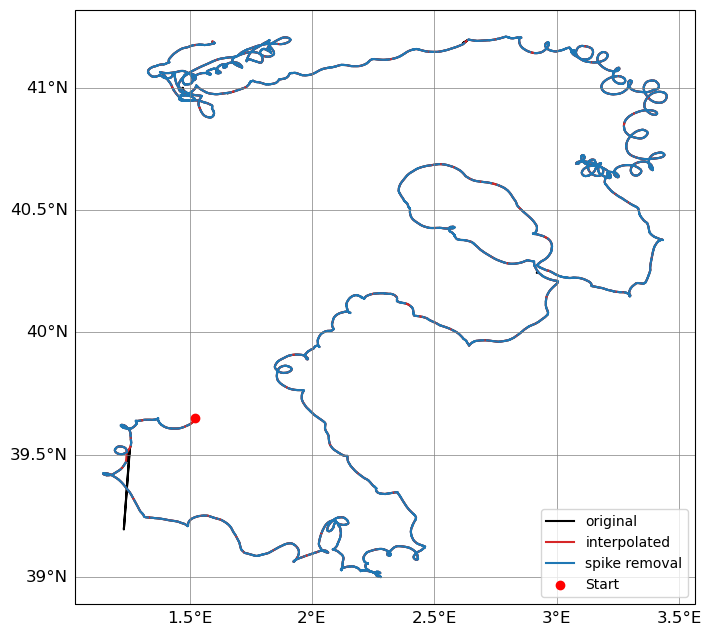

In [52]:
# plt.figure(figsize=(14,10))
# plt.plot(ds05.LON, ds05.LAT, 'C3')
# plt.plot(ds04.LON, ds04.LAT)
# plt.scatter(ds05.LON[1], ds05.LAT[1], c='r')


plt.figure(figsize=(8,8))
ax1 = plt.subplot(111, projection=ccrs.PlateCarree())
ax1.plot(ds00.LON, ds00.LAT, 'k', label='original', transform=ccrs.PlateCarree())
ax1.plot(ds05.LON, ds05.LAT, 'C3', label='interpolated', transform=ccrs.PlateCarree())
ax1.plot(ds04.LON, ds04.LAT, label='spike removal', transform=ccrs.PlateCarree())
ax1.scatter(ds05.LON[0], ds05.LAT[0], c='r', label='Start', transform=ccrs.PlateCarree(), zorder=50)
plt.legend()

# #############
# # Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                               scale='10m', zorder=10,
#                                               edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': 12}#, 'color': 'gray'}
gl.ylabel_style = {'size': 12}#, 'color': 'gray'}
#############

# ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
# ax1.legend()
# ax1.set_title('Trajectory of ' + ds.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

plt.show()




## Zoom:

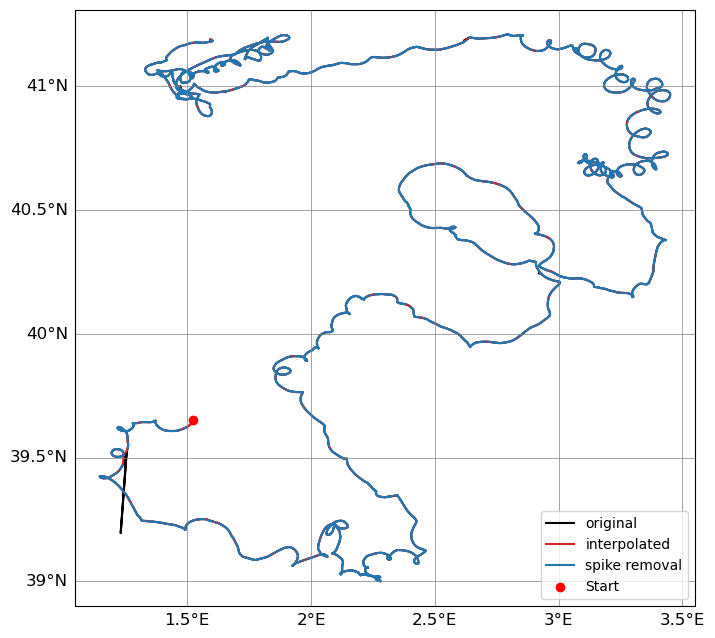

In [53]:
thresa = .1
map_extent = [ds04.LON.min().values - thresa, ds04.LON.max().values + thresa
              , ds04.LAT.min().values - thresa, ds04.LAT.max().values + thresa]

plt.figure(figsize=(8,8))
ax1 = plt.subplot(111, projection=ccrs.PlateCarree())
ax1.plot(ds00.LON, ds00.LAT, 'k', label='original', transform=ccrs.PlateCarree())
ax1.plot(ds05.LON, ds05.LAT, 'C3', label='interpolated', transform=ccrs.PlateCarree())
ax1.plot(ds04.LON, ds04.LAT, label='spike removal', transform=ccrs.PlateCarree())
ax1.scatter(ds05.LON[0], ds05.LAT[0], c='r', label='Start', transform=ccrs.PlateCarree(), zorder=50)
plt.legend()

# #############
# # Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                               scale='10m', zorder=10,
#                                               edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': 12}#, 'color': 'gray'}
gl.ylabel_style = {'size': 12}#, 'color': 'gray'}
#############

ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
# ax1.set_title('Trajectory of ' + ds.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

plt.show()




### 2.5.2. Applying smoothing
To remove small scale noise and any remaining spikes.

(we apply window to smooth the data on the lon and lat drifters, to the recalculate vels (could also apply directly on vels... we will see later) )


# --> for now we leave it at n=12 <-> 2h (method to be refined as smoothes too much at peaks, very flat)

https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html

In [54]:
ds06 = ds05.copy()

Creating new variables with mirror boundary conditions 

(for testing on this see : http://localhost:8889/notebooks/code/drifters/processing/fast_swot_drifter_processing_rough02.ipynb)

In [55]:
nn = 100
lonb = ds05.LON.values
lona = np.flipud(ds05.LON.values[0:nn])
lonc = np.flipud(ds05.LON.values[-nn::])

latb = ds05.LAT.values
lata = np.flipud(ds05.LAT.values[0:nn])
latc = np.flipud(ds05.LAT.values[-nn::])

In [56]:
lon_cat = np.concatenate((lona, lonb, lonc))
lat_cat = np.concatenate((lata, latb, latc))

Applying the window smoothing

In [57]:
window = signal.windows.hamming(12) # 2 hours (12 points) 


In [58]:
lon_win = signal.convolve(lon_cat, window, mode='same') / np.sum(window)
ds06["LON"][:] = lon_win[nn:-nn]

lat_win = signal.convolve(lat_cat, window, mode='same') / np.sum(window)
ds06["LAT"][:] = lat_win[nn:-nn]

In [59]:
ds06

<xarray.Dataset>
Dimensions:        (time: 11719)
Coordinates:
    DEPTH          float64 0.55
  * time           (time) datetime64[ns] 2023-05-10T03:40:00 ... 2023-07-30T1...
Data variables:
    LAT            (time) float64 39.65 39.65 39.64 39.64 ... 41.19 41.19 41.19
    LON            (time) float64 1.52 1.52 1.519 1.518 ... 1.596 1.595 1.595
    PLAT_SPEED_GR  (time) float64 0.4886 0.5005 0.5101 ... -0.5333 -1.387 -2.7
    PLAT_COURSE    (time) float64 -98.58 -108.4 -116.3 ... 130.2 265.5 454.3
    BAT_STATUS     (time) float64 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    U              (time) float64 -0.2821 -0.2936 -0.306 ... 0.4408 0.9064 1.561
    V              (time) float64 -0.98 -0.8673 -0.7623 ... 0.02995 -0.003044
Attributes: (12/67)
    title:                               Data from instrument IME-HEREON018 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-HEREON018 in FaSt-...
    summary:                             Deployment of IME-HEREON018 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

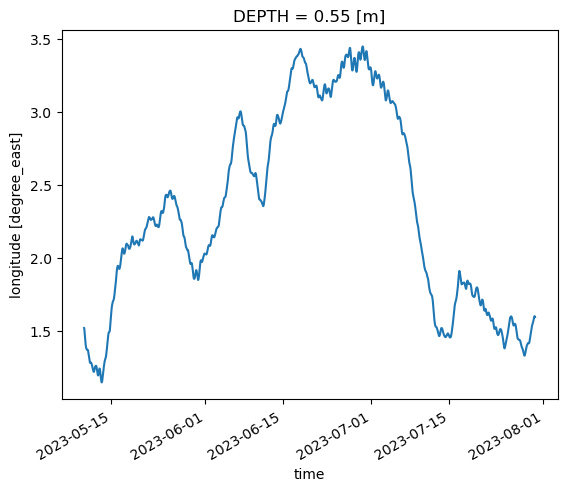

In [60]:
ds06.LON.plot()

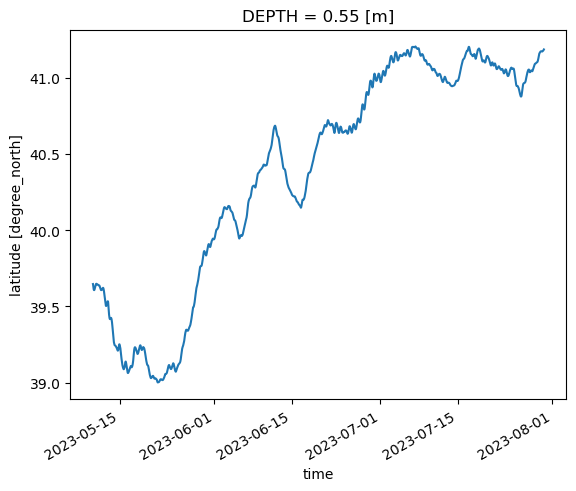

In [61]:
ds06.LAT.plot()

## 2.6. Recalculate U and V:

In [62]:
_, ufor, vfor    = latlon2uv_dir(ds06['LAT'], ds06['LON'], temp_res, 'for') # 600 = temporal resolution
_, uback, vback  = latlon2uv_dir(ds06['LAT'], ds06['LON'], temp_res, 'back')

In [63]:
# Calculate central value
u = (ufor + uback) / 2
v = (vfor + vback) / 2

In [64]:
ds = ds06.copy()

In [65]:
# Add variables to the dataset
ds = ds.assign(U=(ufor+uback)*0.5)
ds = ds.assign(V=(vfor+vback)*0.5)
# ds06 = ds06.assign(UV=(uvabsfor+uvabsback)*0.5)
print(list(ds.keys()))

['LAT', 'LON', 'PLAT_SPEED_GR', 'PLAT_COURSE', 'BAT_STATUS', 'U', 'V']


# Comparing abs. vel before and after smoothing:

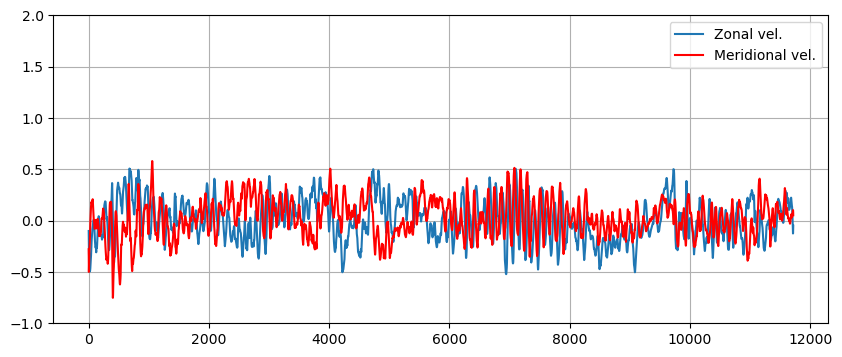

In [66]:
# Limit y axis to see velocity time series
plt.figure(figsize=(10,4))
plt.plot(u, label='Zonal vel.')
plt.plot(v, 'r', label='Meridional vel.')
plt.ylim(-1,2)
plt.legend()
plt.grid()

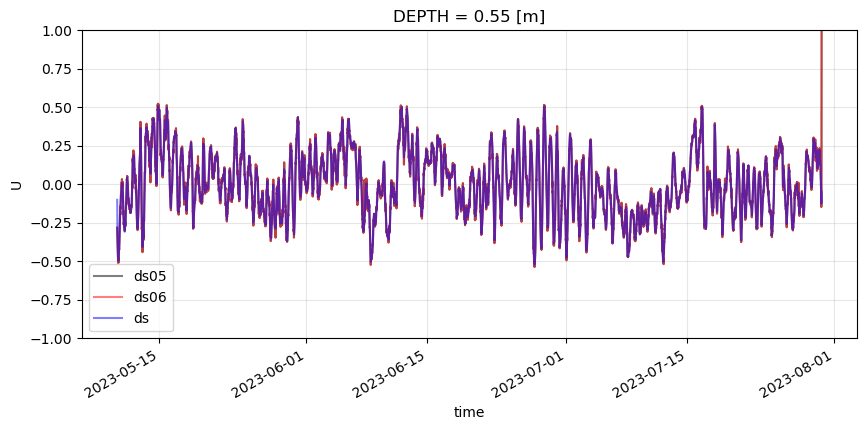

In [67]:
# Limit y axis to see velocity time series
plt.figure(figsize=(10,4))
ds05.U.plot(alpha = 0.5, color = "k", label='ds05');
ds06.U.plot(alpha = 0.5, color = "r", label='ds06');
ds.U.plot(alpha = 0.5, color = "b", label='ds');
plt.ylim(-1,1)
plt.grid(alpha=0.3)
plt.legend()

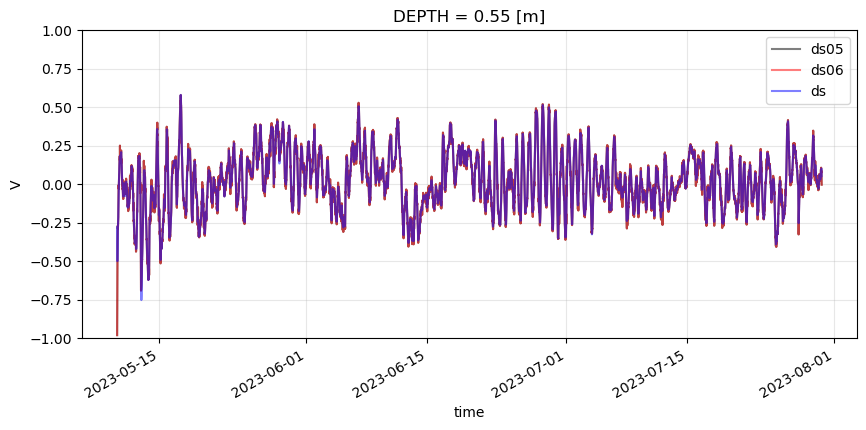

In [68]:
# Limit y axis to see velocity time series
plt.figure(figsize=(10,4))
ds05.V.plot(alpha = 0.5, color = "k", label='ds05');
ds06.V.plot(alpha = 0.5, color = "r", label='ds06');
ds.V.plot(alpha = 0.5, color = "b", label='ds');
plt.ylim(-1,1)
plt.grid(alpha=0.3)
plt.legend()

# Battery:

https://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe036-scb_carthe017/L0/2023/dep0001_drifter-carthe036_scb-carthe017_L0_2023-09-07.nc.html

0 = Low battery, 1 = good

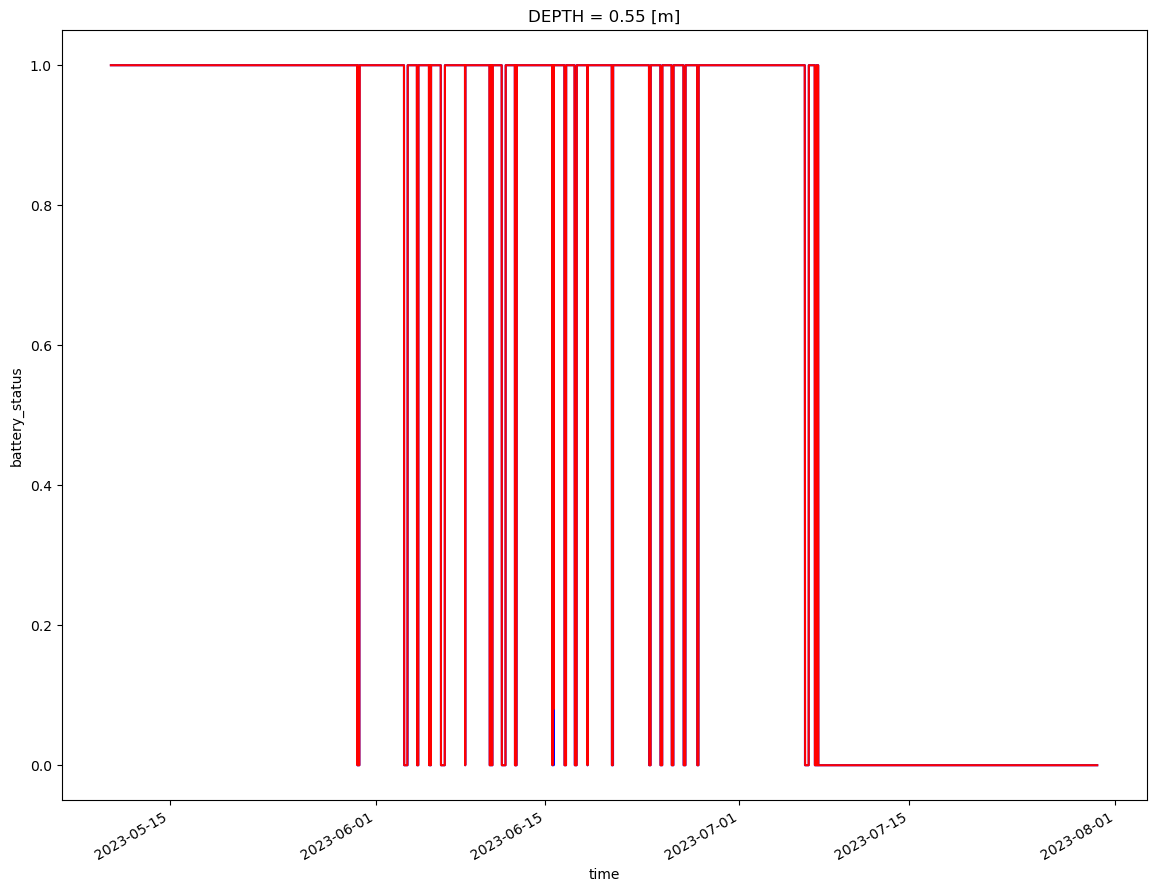

In [69]:
ds00.BAT_STATUS.plot(figsize=(14,10), c='b')
ds.BAT_STATUS.plot(c='r')

# --> well cut already in terms of battery (in this case)

# Flags:

# --> later

# 3. Saving data

In [70]:
rootdir = '../../../../'

In [71]:
outdir = 'data/drifters/L1_IMEDEA/'

In [72]:
fname = url_drifter.split('/')[0] + '.nc'

In [73]:
ds.to_netcdf(rootdir + outdir + fname)

In [74]:
!ls ../../../data/drifters/L1_IMEDEA/

ls: ../../../data/drifters/L1_IMEDEA/: No such file or directory


# 4. Plotting outputs

In [75]:
map_extent=[-0.3, 7.9, 37.9, 41.5]
fsize=14


## (UNTIL WINDOW BORDERS FIXED IGNORE FIRST AND LAST POINTS)

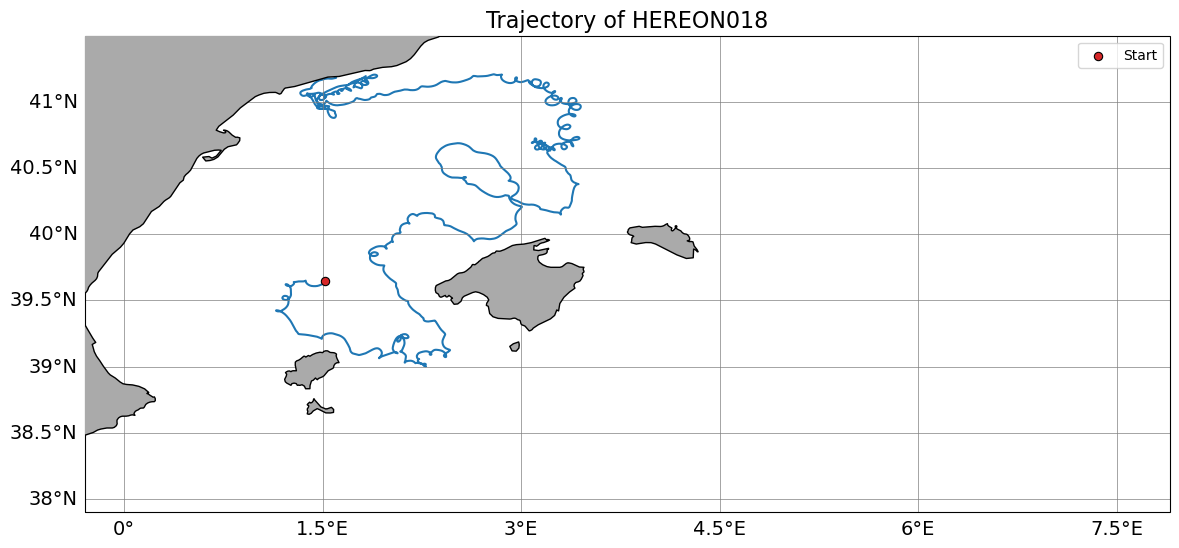

In [76]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
ax1.scatter(ds.LON[0], ds.LAT[0], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='Start', zorder=50)

ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
ax1.legend(loc='best')
ax1.set_title('Trajectory of ' + ds.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

plt.show()

## Velocity:

In [77]:
thresa = .1
map_extent = [ds.LON.min().values - thresa, ds.LON.max().values + thresa, ds.LAT.min().values - thresa, ds.LAT.max().values + thresa]

In [78]:
abs_vel = (ds.U**2 + ds.V**2)**0.5

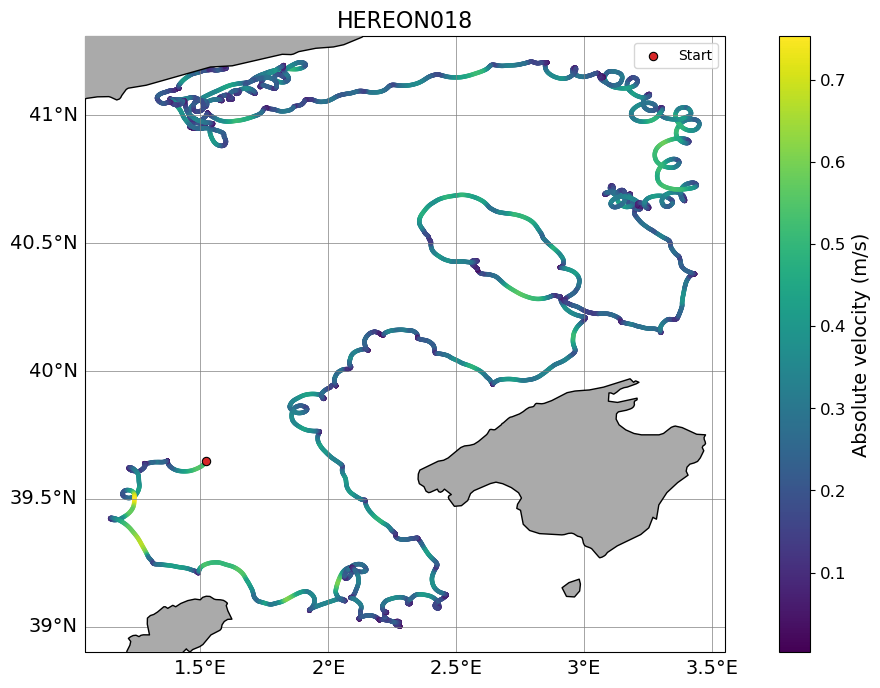

In [79]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

cc = ax1.scatter(ds.LON, ds.LAT, s=5, c=abs_vel, transform=ccrs.PlateCarree())
ax1.scatter(ds.LON[0], ds.LAT[0], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='Start')
cbar = plt.colorbar(cc)
cbar_label = r'Absolute velocity (m/s)'
cbar.ax.tick_params(labelsize=fsize-2)
cbar.ax.set_ylabel(cbar_label, fontsize=fsize)

ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
ax1.legend(loc='best')
ax1.set_title(ds05.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

plt.show()